In [1]:
# ============================================================
# PROJECT 19 — END-TO-END RETAIL ETL & ANALYTICS PIPELINE
# STEP 1 — EXTRACT RAW DATA
# ============================================================

import io
import zipfile
import requests
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

print("=" * 90)
print("PROJECT 19 — END-TO-END RETAIL ETL & ANALYTICS PIPELINE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Download Online Retail II
# ------------------------------------------------------------

url = (
    "https://archive.ics.uci.edu/"
    "static/public/502/online+retail+ii.zip"
)

print("\nDownloading source dataset...")

response = requests.get(
    url,
    timeout=120
)

response.raise_for_status()

print(
    f"Downloaded size: "
    f"{len(response.content) / (1024**2):.2f} MB"
)

# ------------------------------------------------------------
# 2. Open ZIP archive
# ------------------------------------------------------------

with zipfile.ZipFile(
    io.BytesIO(response.content)
) as z:

    print("\nFiles inside ZIP:")

    for file in z.namelist():
        print(" -", file)

    excel_files = [
        file
        for file in z.namelist()
        if file.lower().endswith(
            (".xlsx", ".xls")
        )
    ]

    if not excel_files:
        raise FileNotFoundError(
            "No Excel file found in ZIP archive."
        )

    excel_file = excel_files[0]

    print(
        "\nSelected source file:",
        excel_file
    )

    excel_content = z.read(
        excel_file
    )

# ------------------------------------------------------------
# 3. Inspect workbook
# ------------------------------------------------------------

xls = pd.ExcelFile(
    io.BytesIO(
        excel_content
    )
)

print(
    "\nAvailable sheets:"
)

for sheet in xls.sheet_names:
    print(
        " -",
        sheet
    )

# ------------------------------------------------------------
# 4. Extract all sheets
# ------------------------------------------------------------

raw_frames = []

for sheet_name in xls.sheet_names:

    print(
        f"\nExtracting sheet: "
        f"{sheet_name}"
    )

    sheet_df = pd.read_excel(
        xls,
        sheet_name=sheet_name
    )

    # Preserve source lineage
    sheet_df[
        "Source_Sheet"
    ] = sheet_name

    print(
        f"Rows extracted: "
        f"{len(sheet_df):,}"
    )

    raw_frames.append(
        sheet_df
    )

# ------------------------------------------------------------
# 5. Combine all source sheets
# ------------------------------------------------------------

raw_df = pd.concat(
    raw_frames,
    ignore_index=True
)

# ------------------------------------------------------------
# 6. Standardize column names
# ------------------------------------------------------------

raw_df.columns = [
    str(col).strip()
    for col in raw_df.columns
]

# ------------------------------------------------------------
# 7. Extraction profiling
# ------------------------------------------------------------

raw_profile = pd.DataFrame({
    "Column":
        raw_df.columns,

    "Data_Type": [
        str(raw_df[col].dtype)
        for col in raw_df.columns
    ],

    "Missing":
        [
            raw_df[col]
            .isna()
            .sum()
            for col in raw_df.columns
        ],

    "Unique_Values":
        [
            raw_df[col]
            .nunique(
                dropna=False
            )
            for col in raw_df.columns
        ]
})

raw_profile[
    "Missing_Rate_%"
] = (
    raw_profile[
        "Missing"
    ]
    /
    len(raw_df)
    *
    100
)

# ------------------------------------------------------------
# 8. Display extraction results
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "RAW DATA EXTRACTION RESULT"
)

print(
    "=" * 90
)

print(
    f"\nTotal rows       : "
    f"{len(raw_df):,}"
)

print(
    f"Total columns    : "
    f"{len(raw_df.columns)}"
)

print(
    f"Duplicate rows   : "
    f"{raw_df.duplicated().sum():,}"
)

print(
    f"Missing cells    : "
    f"{raw_df.isna().sum().sum():,}"
)

print(
    "\nColumns:"
)

print(
    raw_df.columns.tolist()
)

print(
    "\nRaw data profile:"
)

display(
    raw_profile
)

print(
    "\nFirst 10 records:"
)

display(
    raw_df.head(10)
)

# ------------------------------------------------------------
# 9. Source sheet distribution
# ------------------------------------------------------------

if "Source_Sheet" in raw_df.columns:

    print(
        "\nSource sheet distribution:"
    )

    display(
        raw_df[
            "Source_Sheet"
        ]
        .value_counts()
        .to_frame(
            "Rows"
        )
    )

# ------------------------------------------------------------
# 10. Date coverage
# ------------------------------------------------------------

if "InvoiceDate" in raw_df.columns:

    temp_dates = pd.to_datetime(
        raw_df[
            "InvoiceDate"
        ],
        errors="coerce"
    )

    print(
        "\nDate coverage:"
    )

    print(
        "Minimum:",
        temp_dates.min()
    )

    print(
        "Maximum:",
        temp_dates.max()
    )

# ------------------------------------------------------------
# 11. Customer coverage
# ------------------------------------------------------------

if "Customer ID" in raw_df.columns:

    print(
        "\nCustomer coverage:"
    )

    print(
        "Rows with Customer ID:",
        raw_df[
            "Customer ID"
        ]
        .notna()
        .sum()
    )

    print(
        "Unique Customer IDs:",
        raw_df[
            "Customer ID"
        ]
        .nunique(
            dropna=True
        )
    )

# ------------------------------------------------------------
# 12. Final extraction status
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "EXTRACTION STATUS"
)

print(
    "=" * 90
)

print(
    "PASS — Full raw dataset extracted successfully."
)

PROJECT 19 — END-TO-END RETAIL ETL & ANALYTICS PIPELINE

Downloaded size: 43.51 MB

Files inside ZIP:
 - online_retail_II.xlsx

Selected source file: online_retail_II.xlsx

Available sheets:
 - Year 2009-2010
 - Year 2010-2011

Extracting sheet: Year 2009-2010
Rows extracted: 525,461

Extracting sheet: Year 2010-2011
Rows extracted: 541,910

RAW DATA EXTRACTION RESULT

Total rows       : 1,067,371
Total columns    : 9
Duplicate rows   : 12,133
Missing cells    : 247,389

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Source_Sheet']

Raw data profile:


,Column,Data_Type,Missing,Unique_Values,Missing_Rate_%
0,Invoice,object,0,53628,0.000000
1,StockCode,object,0,5305,0.000000
2,Description,object,4382,5699,0.410541
3,Quantity,int64,0,1057,0.000000
4,InvoiceDate,datetime64[ns],0,47635,0.000000
5,Price,float64,0,2807,0.000000
6,Customer ID,float64,243007,5943,22.766873
7,Country,object,0,43,0.000000
8,Source_Sheet,object,0,2,0.000000



First 10 records:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Source_Sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,Year 2009-2010
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,Year 2009-2010
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,Year 2009-2010
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,Year 2009-2010



Source sheet distribution:


,Rows
Source_Sheet,
Year 2010-2011,541910
Year 2009-2010,525461



Date coverage:
Minimum: 2009-12-01 07:45:00
Maximum: 2011-12-09 12:50:00

Customer coverage:
Rows with Customer ID: 824364
Unique Customer IDs: 5942

EXTRACTION STATUS
PASS — Full raw dataset extracted successfully.


In [2]:
# ============================================================
# PROJECT 19 — END-TO-END RETAIL ETL & ANALYTICS PIPELINE
# STEP 2 — TRANSFORM, CLEAN & DATA QUALITY GATE
# ============================================================

import pandas as pd
import numpy as np

print("=" * 90)
print("TRANSFORM & DATA QUALITY GATE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Copy raw layer
# ------------------------------------------------------------

transform_df = raw_df.copy()

raw_row_count = len(
    transform_df
)

# ------------------------------------------------------------
# 2. Standardize column names
# ------------------------------------------------------------

transform_df = transform_df.rename(
    columns={
        "Invoice": "InvoiceNo",
        "StockCode": "StockCode",
        "Description": "Description",
        "Quantity": "Quantity",
        "InvoiceDate": "InvoiceDate",
        "Price": "UnitPrice",
        "Customer ID": "CustomerID",
        "Country": "Country"
    }
)

# ------------------------------------------------------------
# 3. Preserve source lineage
# ------------------------------------------------------------

if "Source_Sheet" not in transform_df.columns:

    transform_df[
        "Source_Sheet"
    ] = "Unknown"

# ------------------------------------------------------------
# 4. Data type conversion
# ------------------------------------------------------------

transform_df[
    "InvoiceDate"
] = pd.to_datetime(
    transform_df[
        "InvoiceDate"
    ],
    errors="coerce"
)

transform_df[
    "Quantity"
] = pd.to_numeric(
    transform_df[
        "Quantity"
    ],
    errors="coerce"
)

transform_df[
    "UnitPrice"
] = pd.to_numeric(
    transform_df[
        "UnitPrice"
    ],
    errors="coerce"
)

transform_df[
    "CustomerID"
] = pd.to_numeric(
    transform_df[
        "CustomerID"
    ],
    errors="coerce"
)

# ------------------------------------------------------------
# 5. Initial data quality checks
# ------------------------------------------------------------

initial_missing_customer = (
    transform_df[
        "CustomerID"
    ].isna().sum()
)

initial_duplicates = (
    transform_df
    .duplicated()
    .sum()
)

initial_invalid_dates = (
    transform_df[
        "InvoiceDate"
    ].isna()
    .sum()
)

initial_invalid_quantity = (
    transform_df[
        "Quantity"
    ].isna()
    .sum()
)

initial_invalid_price = (
    transform_df[
        "UnitPrice"
    ].isna()
    .sum()
)

# ------------------------------------------------------------
# 6. Remove rows without CustomerID
# ------------------------------------------------------------

customer_filtered_df = (
    transform_df[
        transform_df[
            "CustomerID"
        ].notna()
    ]
    .copy()
)

# ------------------------------------------------------------
# 7. Remove exact duplicates
# ------------------------------------------------------------

duplicates_removed = (
    customer_filtered_df
    .duplicated()
    .sum()
)

customer_filtered_df = (
    customer_filtered_df
    .drop_duplicates()
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 8. Validate invoice identifiers
# ------------------------------------------------------------

customer_filtered_df[
    "InvoiceNo"
] = (
    customer_filtered_df[
        "InvoiceNo"
    ]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 9. Identify cancellations
# ------------------------------------------------------------

customer_filtered_df[
    "IsCancellation"
] = (
    customer_filtered_df[
        "InvoiceNo"
    ]
    .str.upper()
    .str.startswith("C")
)

cancellation_count = (
    customer_filtered_df[
        "IsCancellation"
    ]
    .sum()
)

# ------------------------------------------------------------
# 10. Validate transaction values
# ------------------------------------------------------------

invalid_quantity_count = (
    (
        customer_filtered_df[
            "Quantity"
        ] <= 0
    )
    |
    customer_filtered_df[
        "Quantity"
    ].isna()
).sum()

invalid_price_count = (
    (
        customer_filtered_df[
            "UnitPrice"
        ] <= 0
    )
    |
    customer_filtered_df[
        "UnitPrice"
    ].isna()
).sum()

invalid_date_count = (
    customer_filtered_df[
        "InvoiceDate"
    ].isna()
    .sum()
)

# ------------------------------------------------------------
# 11. Create transformed revenue field
# ------------------------------------------------------------

customer_filtered_df[
    "Revenue"
] = (
    customer_filtered_df[
        "Quantity"
    ]
    *
    customer_filtered_df[
        "UnitPrice"
    ]
)

# ------------------------------------------------------------
# 12. Keep valid sales transactions
# ------------------------------------------------------------

sales_df = (
    customer_filtered_df[
        (
            ~customer_filtered_df[
                "IsCancellation"
            ]
        )
        &
        (
            customer_filtered_df[
                "Quantity"
            ] > 0
        )
        &
        (
            customer_filtered_df[
                "UnitPrice"
            ] > 0
        )
        &
        (
            customer_filtered_df[
                "InvoiceDate"
            ].notna()
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# 13. Standardize text fields
# ------------------------------------------------------------

sales_df[
    "StockCode"
] = (
    sales_df[
        "StockCode"
    ]
    .astype(str)
    .str.strip()
)

sales_df[
    "Description"
] = (
    sales_df[
        "Description"
    ]
    .fillna(
        "Unknown Product"
    )
    .astype(str)
    .str.strip()
)

sales_df[
    "Country"
] = (
    sales_df[
        "Country"
    ]
    .fillna(
        "Unknown"
    )
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 14. Standardize CustomerID
# ------------------------------------------------------------

sales_df[
    "CustomerID"
] = (
    sales_df[
        "CustomerID"
    ]
    .astype(int)
)

# ------------------------------------------------------------
# 15. Final duplicate check
# ------------------------------------------------------------

final_duplicates = (
    sales_df
    .duplicated()
    .sum()
)

# ------------------------------------------------------------
# 16. Final missing-value check
# ------------------------------------------------------------

final_missing = (
    sales_df
    .isna()
    .sum()
    .sum()
)

# ------------------------------------------------------------
# 17. Final business-rule validation
# ------------------------------------------------------------

final_invalid_quantity = (
    sales_df[
        "Quantity"
    ] <= 0
).sum()

final_invalid_price = (
    sales_df[
        "UnitPrice"
    ] <= 0
).sum()

final_invalid_revenue = (
    sales_df[
        "Revenue"
    ] <= 0
).sum()

# ------------------------------------------------------------
# 18. Create quality gate
# ------------------------------------------------------------

quality_gate_checks = {

    "Missing_CustomerID":
        sales_df[
            "CustomerID"
        ].isna().sum(),

    "Missing_InvoiceDate":
        sales_df[
            "InvoiceDate"
        ].isna().sum(),

    "Invalid_Quantity":
        final_invalid_quantity,

    "Invalid_UnitPrice":
        final_invalid_price,

    "Invalid_Revenue":
        final_invalid_revenue,

    "Duplicate_Rows":
        final_duplicates
}

quality_gate = pd.DataFrame({
    "Check":
        list(
            quality_gate_checks.keys()
        ),

    "Issue_Count":
        list(
            quality_gate_checks.values()
        )
})

quality_gate[
    "Status"
] = np.where(
    quality_gate[
        "Issue_Count"
    ] == 0,
    "PASS",
    "REJECT"
)

overall_quality_status = (
    "PASS"
    if (
        quality_gate[
            "Status"
        ] == "PASS"
    ).all()
    else
    "REJECT"
)

# ------------------------------------------------------------
# 19. Transformation summary
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "TRANSFORMATION SUMMARY"
)

print(
    "=" * 90
)

print(
    f"\nRaw rows                  : "
    f"{raw_row_count:,}"
)

print(
    f"Missing CustomerID       : "
    f"{initial_missing_customer:,}"
)

print(
    f"Rows after CustomerID    : "
    f"{len(customer_filtered_df):,}"
)

print(
    f"Duplicates removed       : "
    f"{duplicates_removed:,}"
)

print(
    f"Cancellations identified : "
    f"{cancellation_count:,}"
)

print(
    f"Invalid quantity rows    : "
    f"{invalid_quantity_count:,}"
)

print(
    f"Invalid price rows       : "
    f"{invalid_price_count:,}"
)

print(
    f"Invalid date rows        : "
    f"{invalid_date_count:,}"
)

print(
    f"\nFinal sales rows         : "
    f"{len(sales_df):,}"
)

print(
    f"Unique customers         : "
    f"{sales_df['CustomerID'].nunique():,}"
)

print(
    f"Unique invoices          : "
    f"{sales_df['InvoiceNo'].nunique():,}"
)

print(
    f"Unique products          : "
    f"{sales_df['StockCode'].nunique():,}"
)

print(
    f"Countries                : "
    f"{sales_df['Country'].nunique():,}"
)

print(
    f"Total revenue            : "
    f"{sales_df['Revenue'].sum():,.2f}"
)

# ------------------------------------------------------------
# 20. Quality gate output
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "DATA QUALITY GATE"
)

print(
    "=" * 90
)

display(
    quality_gate
)

print(
    f"\nPIPELINE QUALITY STATUS: "
    f"{overall_quality_status}"
)

# ------------------------------------------------------------
# 21. Final sample
# ------------------------------------------------------------

print(
    "\nFinal transformed dataset:"
)

display(
    sales_df.head(10)
)

# ------------------------------------------------------------
# 22. Revenue summary
# ------------------------------------------------------------

print(
    "\nRevenue summary:"
)

display(
    sales_df[
        "Revenue"
    ]
    .describe()
    .to_frame(
        "Revenue"
    )
)

TRANSFORM & DATA QUALITY GATE

TRANSFORMATION SUMMARY

Raw rows                  : 1,067,371
Missing CustomerID       : 243,007
Rows after CustomerID    : 812,368
Duplicates removed       : 11,996
Cancellations identified : 18,688
Invalid quantity rows    : 18,688
Invalid price rows       : 71
Invalid date rows        : 0

Final sales rows         : 793,609
Unique customers         : 5,878
Unique invoices          : 36,969
Unique products          : 4,631
Countries                : 41
Total revenue            : 17,685,460.64

DATA QUALITY GATE


,Check,Issue_Count,Status
0,Missing_CustomerID,0,PASS
1,Missing_InvoiceDate,0,PASS
2,Invalid_Quantity,0,PASS
3,Invalid_UnitPrice,0,PASS
4,Invalid_Revenue,0,PASS
5,Duplicate_Rows,0,PASS



PIPELINE QUALITY STATUS: PASS

Final transformed dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Source_Sheet,IsCancellation,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,False,30.0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,Year 2009-2010,False,39.6
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,False,30.0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,Year 2009-2010,False,59.5
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,Year 2009-2010,False,30.6
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom,Year 2009-2010,False,45.0



Revenue summary:


,Revenue
count,793609.000000
mean,22.284854
std,225.708594
min,0.001000
25%,4.950000
50%,12.480000
75%,19.800000
max,168469.600000


In [6]:
import pandas as pd
import numpy as np

print("=" * 90)
print("BUILDING ANALYTICAL STAR SCHEMA")
print("=" * 90)

# ------------------------------------------------------------
# 1. Prepare source data
# ------------------------------------------------------------

star_source = (
    sales_df
    .copy()
    .reset_index(drop=True)
)

# Create a unique transaction-line identifier
star_source[
    "SalesKey"
] = np.arange(
    1,
    len(star_source) + 1
)

star_source[
    "InvoiceDate"
] = pd.to_datetime(
    star_source[
        "InvoiceDate"
    ],
    errors="coerce"
)

# ------------------------------------------------------------
# 2. DIM_DATE
# ------------------------------------------------------------

date_values = (
    star_source[
        "InvoiceDate"
    ]
    .dt.normalize()
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

dim_date = pd.DataFrame({
    "Date": date_values
})

dim_date[
    "DateKey"
] = (
    dim_date[
        "Date"
    ]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

dim_date[
    "Year"
] = (
    dim_date[
        "Date"
    ].dt.year
)

dim_date[
    "Quarter"
] = (
    dim_date[
        "Date"
    ].dt.quarter
)

dim_date[
    "Month"
] = (
    dim_date[
        "Date"
    ].dt.month
)

dim_date[
    "MonthName"
] = (
    dim_date[
        "Date"
    ].dt.month_name()
)

dim_date[
    "WeekOfYear"
] = (
    dim_date[
        "Date"
    ]
    .dt.isocalendar()
    .week
    .astype(int)
)

dim_date[
    "Day"
] = (
    dim_date[
        "Date"
    ].dt.day
)

dim_date[
    "DayOfWeek"
] = (
    dim_date[
        "Date"
    ].dt.dayofweek
)

dim_date[
    "DayName"
] = (
    dim_date[
        "Date"
    ].dt.day_name()
)

dim_date[
    "IsWeekend"
] = (
    dim_date[
        "DayOfWeek"
    ] >= 5
).astype(int)

dim_date = (
    dim_date[
        [
            "DateKey",
            "Date",
            "Year",
            "Quarter",
            "Month",
            "MonthName",
            "WeekOfYear",
            "Day",
            "DayOfWeek",
            "DayName",
            "IsWeekend"
        ]
    ]
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. DIM_CUSTOMER
# ------------------------------------------------------------

dim_customer = (
    star_source[
        [
            "CustomerID",
            "Country"
        ]
    ]
    .drop_duplicates(
        subset=[
            "CustomerID"
        ]
    )
    .copy()
)

dim_customer[
    "CustomerID"
] = (
    dim_customer[
        "CustomerID"
    ]
    .astype(int)
)

dim_customer = (
    dim_customer
    .sort_values(
        "CustomerID"
    )
    .reset_index(drop=True)
)

dim_customer[
    "CustomerKey"
] = np.arange(
    1,
    len(dim_customer) + 1
)

dim_customer = (
    dim_customer[
        [
            "CustomerKey",
            "CustomerID",
            "Country"
        ]
    ]
)

# ------------------------------------------------------------
# 4. DIM_PRODUCT
# ------------------------------------------------------------

dim_product = (
    star_source[
        [
            "StockCode",
            "Description"
        ]
    ]
    .copy()
)

dim_product[
    "StockCode"
] = (
    dim_product[
        "StockCode"
    ]
    .astype(str)
    .str.strip()
)

dim_product[
    "Description"
] = (
    dim_product[
        "Description"
    ]
    .fillna(
        "Unknown Product"
    )
    .astype(str)
    .str.strip()
)

dim_product = (
    dim_product
    .drop_duplicates(
        subset=[
            "StockCode"
        ]
    )
    .sort_values(
        "StockCode"
    )
    .reset_index(drop=True)
)

dim_product[
    "ProductKey"
] = np.arange(
    1,
    len(dim_product) + 1
)

dim_product = (
    dim_product[
        [
            "ProductKey",
            "StockCode",
            "Description"
        ]
    ]
)

# ------------------------------------------------------------
# 5. DIM_COUNTRY
# ------------------------------------------------------------

dim_country = (
    star_source[
        [
            "Country"
        ]
    ]
    .drop_duplicates()
    .copy()
)

dim_country[
    "Country"
] = (
    dim_country[
        "Country"
    ]
    .fillna(
        "Unknown"
    )
    .astype(str)
    .str.strip()
)

dim_country = (
    dim_country
    .sort_values(
        "Country"
    )
    .reset_index(drop=True)
)

dim_country[
    "CountryKey"
] = np.arange(
    1,
    len(dim_country) + 1
)

dim_country = (
    dim_country[
        [
            "CountryKey",
            "Country"
        ]
    ]
)

# ------------------------------------------------------------
# 6. Mapping tables
# ------------------------------------------------------------

customer_map = (
    dim_customer[
        [
            "CustomerKey",
            "CustomerID"
        ]
    ]
)

product_map = (
    dim_product[
        [
            "ProductKey",
            "StockCode"
        ]
    ]
)

country_map = (
    dim_country[
        [
            "CountryKey",
            "Country"
        ]
    ]
)

date_map = (
    dim_date[
        [
            "DateKey",
            "Date"
        ]
    ]
)

# ------------------------------------------------------------
# 7. Build FACT_SALES
# ------------------------------------------------------------

fact_sales = (
    star_source
    .merge(
        customer_map,
        on="CustomerID",
        how="left",
        validate="many_to_one"
    )
)

fact_sales = (
    fact_sales
    .merge(
        product_map,
        on="StockCode",
        how="left",
        validate="many_to_one"
    )
)

fact_sales[
    "Date"
] = (
    fact_sales[
        "InvoiceDate"
    ]
    .dt.normalize()
)

fact_sales = (
    fact_sales
    .merge(
        date_map,
        on="Date",
        how="left",
        validate="many_to_one"
    )
)

fact_sales = (
    fact_sales
    .merge(
        country_map,
        on="Country",
        how="left",
        validate="many_to_one"
    )
)

# ------------------------------------------------------------
# 8. Keep one row per transaction line
# ------------------------------------------------------------

fact_sales = (
    fact_sales[
        [
            "SalesKey",
            "InvoiceNo",
            "CustomerKey",
            "ProductKey",
            "DateKey",
            "CountryKey",
            "Quantity",
            "UnitPrice",
            "Revenue"
        ]
    ]
    .copy()
)

fact_sales = (
    fact_sales
    .sort_values(
        "SalesKey"
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 9. Validate SalesKey
# ------------------------------------------------------------

saleskey_missing = (
    fact_sales[
        "SalesKey"
    ]
    .isna()
    .sum()
)

saleskey_duplicates = (
    fact_sales[
        "SalesKey"
    ]
    .duplicated()
    .sum()
)

# ------------------------------------------------------------
# 10. Foreign key validation
# ------------------------------------------------------------

foreign_key_checks = pd.DataFrame({
    "Check": [
        "CustomerKey",
        "ProductKey",
        "DateKey",
        "CountryKey"
    ],

    "Missing_Keys": [
        fact_sales[
            "CustomerKey"
        ].isna().sum(),

        fact_sales[
            "ProductKey"
        ].isna().sum(),

        fact_sales[
            "DateKey"
        ].isna().sum(),

        fact_sales[
            "CountryKey"
        ].isna().sum()
    ]
})

foreign_key_checks[
    "Status"
] = np.where(
    foreign_key_checks[
        "Missing_Keys"
    ] == 0,
    "PASS",
    "ALERT"
)

# ------------------------------------------------------------
# 11. Fact validation
# ------------------------------------------------------------

fact_validation = pd.DataFrame({
    "Check": [
        "Fact Rows",
        "Missing SalesKey",
        "Duplicate SalesKey",
        "Missing Revenue",
        "Invalid Quantity",
        "Invalid UnitPrice",
        "Missing Foreign Keys"
    ],

    "Value": [
        len(fact_sales),

        saleskey_missing,

        saleskey_duplicates,

        fact_sales[
            "Revenue"
        ].isna().sum(),

        (
            fact_sales[
                "Quantity"
            ] <= 0
        ).sum(),

        (
            fact_sales[
                "UnitPrice"
            ] <= 0
        ).sum(),

        foreign_key_checks[
            "Missing_Keys"
        ].sum()
    ]
})

# ------------------------------------------------------------
# 12. Warehouse validation
# ------------------------------------------------------------

warehouse_issue_count = (
    fact_validation[
        "Value"
    ]
    .iloc[1:]
    .sum()
)

warehouse_status = (
    "PASS"
    if warehouse_issue_count == 0
    else "ALERT"
)

# ------------------------------------------------------------
# 13. Revenue reconciliation
# ------------------------------------------------------------

source_revenue = (
    sales_df[
        "Revenue"
    ]
    .sum()
)

warehouse_revenue = (
    fact_sales[
        "Revenue"
    ]
    .sum()
)

revenue_difference = (
    source_revenue
    -
    warehouse_revenue
)

revenue_status = (
    "PASS"
    if abs(
        revenue_difference
    ) < 0.01
    else "ALERT"
)

# ------------------------------------------------------------
# 14. Display schema summary
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "STAR SCHEMA SUMMARY"
)

print(
    "=" * 90
)

print(
    f"\nFACT_SALES rows     : "
    f"{len(fact_sales):,}"
)

print(
    f"DIM_CUSTOMER rows   : "
    f"{len(dim_customer):,}"
)

print(
    f"DIM_PRODUCT rows    : "
    f"{len(dim_product):,}"
)

print(
    f"DIM_DATE rows       : "
    f"{len(dim_date):,}"
)

print(
    f"DIM_COUNTRY rows    : "
    f"{len(dim_country):,}"
)

# ------------------------------------------------------------
# 15. Foreign key checks
# ------------------------------------------------------------

print(
    "\nForeign key validation:"
)

display(
    foreign_key_checks
)

# ------------------------------------------------------------
# 16. Fact checks
# ------------------------------------------------------------

print(
    "\nFact table validation:"
)

display(
    fact_validation
)

print(
    f"\nWAREHOUSE VALIDATION STATUS: "
    f"{warehouse_status}"
)

# ------------------------------------------------------------
# 17. Revenue reconciliation
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "REVENUE RECONCILIATION"
)

print(
    "=" * 90
)

print(
    f"Source revenue    : "
    f"{source_revenue:,.2f}"
)

print(
    f"Warehouse revenue : "
    f"{warehouse_revenue:,.2f}"
)

print(
    f"Difference        : "
    f"{revenue_difference:,.2f}"
)

print(
    f"Status            : "
    f"{revenue_status}"
)

# ------------------------------------------------------------
# 18. Check transaction-line grain
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "FACT TABLE GRAIN"
)

print(
    "=" * 90
)

print(
    "One row = one transaction line"
)

print(
    f"Unique SalesKey   : "
    f"{fact_sales['SalesKey'].nunique():,}"
)

print(
    f"Fact rows         : "
    f"{len(fact_sales):,}"
)

print(
    "Grain validation  : "
    +
    (
        "PASS"
        if (
            fact_sales["SalesKey"].nunique()
            ==
            len(fact_sales)
        )
        else
        "ALERT"
    )
)

# ------------------------------------------------------------
# 19. Display tables
# ------------------------------------------------------------

print(
    "\nFACT_SALES:"
)

display(
    fact_sales.head(10)
)

print(
    "\nDIM_CUSTOMER:"
)

display(
    dim_customer.head(10)
)

print(
    "\nDIM_PRODUCT:"
)

display(
    dim_product.head(10)
)

print(
    "\nDIM_DATE:"
)

display(
    dim_date.head(10)
)

print(
    "\nDIM_COUNTRY:"
)

display(
    dim_country.head(10)
)

# ------------------------------------------------------------
# 20. Final status
# ------------------------------------------------------------

final_star_schema_status = (
    "PASS"
    if (
        warehouse_status == "PASS"
        and revenue_status == "PASS"
        and saleskey_duplicates == 0
    )
    else "ALERT"
)

print(
    "\n" + "=" * 90
)

print(
    "FINAL STAR SCHEMA STATUS"
)

print(
    "=" * 90
)

print(
    f"Status: {final_star_schema_status}"
)


BUILDING ANALYTICAL STAR SCHEMA

STAR SCHEMA SUMMARY

FACT_SALES rows     : 793,609
DIM_CUSTOMER rows   : 5,878
DIM_PRODUCT rows    : 4,631
DIM_DATE rows       : 604
DIM_COUNTRY rows    : 41

Foreign key validation:


,Check,Missing_Keys,Status
0,CustomerKey,0,PASS
1,ProductKey,0,PASS
2,DateKey,0,PASS
3,CountryKey,0,PASS



Fact table validation:


,Check,Value
0,Fact Rows,793609
1,Missing SalesKey,0
2,Duplicate SalesKey,0
3,Missing Revenue,0
4,Invalid Quantity,0
5,Invalid UnitPrice,0
6,Missing Foreign Keys,0



WAREHOUSE VALIDATION STATUS: PASS

REVENUE RECONCILIATION
Source revenue    : 17,685,460.64
Warehouse revenue : 17,685,460.64
Difference        : 0.00
Status            : PASS

FACT TABLE GRAIN
One row = one transaction line
Unique SalesKey   : 793,609
Fact rows         : 793,609
Grain validation  : PASS

FACT_SALES:


...


DIM_DATE:


,DateKey,Date,Year,Quarter,Month,MonthName,WeekOfYear,Day,DayOfWeek,DayName,IsWeekend
0,20091201,2009-12-01,2009,4,12,December,49,1,1,Tuesday,0
1,20091202,2009-12-02,2009,4,12,December,49,2,2,Wednesday,0
2,20091203,2009-12-03,2009,4,12,December,49,3,3,Thursday,0
3,20091204,2009-12-04,2009,4,12,December,49,4,4,Friday,0
4,20091205,2009-12-05,2009,4,12,December,49,5,5,Saturday,1
5,20091206,2009-12-06,2009,4,12,December,49,6,6,Sunday,1
6,20091207,2009-12-07,2009,4,12,December,50,7,0,Monday,0
7,20091208,2009-12-08,2009,4,12,December,50,8,1,Tuesday,0
8,20091209,2009-12-09,2009,4,12,December,50,9,2,Wednesday,0
9,20091210,2009-12-10,2009,4,12,December,50,10,3,Thursday,0



DIM_COUNTRY:


,CountryKey,Country
0,1,Australia
1,2,Austria
2,3,Bahrain
3,4,Belgium
4,5,Brazil
5,6,Canada
6,7,Channel Islands
7,8,Cyprus
8,9,Czech Republic
9,10,Denmark



FINAL STAR SCHEMA STATUS
Status: PASS


In [7]:
# ============================================================
# PROJECT 19 — END-TO-END RETAIL ETL & ANALYTICS PIPELINE
# STEP 4 — LOAD STAR SCHEMA INTO SQLITE
# ============================================================

import sqlite3
import pandas as pd
import numpy as np
import os

print("=" * 90)
print("LOADING STAR SCHEMA INTO SQLITE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Database configuration
# ------------------------------------------------------------

db_path = "retail_analytics.db"

# Remove previous database if it exists
if os.path.exists(db_path):
    os.remove(db_path)

# ------------------------------------------------------------
# 2. Create SQLite connection
# ------------------------------------------------------------

conn = sqlite3.connect(
    db_path
)

# ------------------------------------------------------------
# 3. Load dimension tables
# ------------------------------------------------------------

print("\nLoading DIM_CUSTOMER...")

dim_customer.to_sql(
    "dim_customer",
    conn,
    if_exists="replace",
    index=False
)

print(
    f"Loaded {len(dim_customer):,} rows"
)

print("\nLoading DIM_PRODUCT...")

dim_product.to_sql(
    "dim_product",
    conn,
    if_exists="replace",
    index=False
)

print(
    f"Loaded {len(dim_product):,} rows"
)

print("\nLoading DIM_DATE...")

dim_date.to_sql(
    "dim_date",
    conn,
    if_exists="replace",
    index=False
)

print(
    f"Loaded {len(dim_date):,} rows"
)

print("\nLoading DIM_COUNTRY...")

dim_country.to_sql(
    "dim_country",
    conn,
    if_exists="replace",
    index=False
)

print(
    f"Loaded {len(dim_country):,} rows"
)

# ------------------------------------------------------------
# 4. Load fact table
# ------------------------------------------------------------

print("\nLoading FACT_SALES...")

fact_sales.to_sql(
    "fact_sales",
    conn,
    if_exists="replace",
    index=False
)

print(
    f"Loaded {len(fact_sales):,} rows"
)

# ------------------------------------------------------------
# 5. Create indexes
# ------------------------------------------------------------

print(
    "\nCreating database indexes..."
)

index_queries = [

    """
    CREATE INDEX idx_fact_customer
    ON fact_sales(CustomerKey)
    """,

    """
    CREATE INDEX idx_fact_product
    ON fact_sales(ProductKey)
    """,

    """
    CREATE INDEX idx_fact_date
    ON fact_sales(DateKey)
    """,

    """
    CREATE INDEX idx_fact_country
    ON fact_sales(CountryKey)
    """,

    """
    CREATE INDEX idx_fact_invoice
    ON fact_sales(InvoiceNo)
    """

]

for query in index_queries:

    conn.execute(
        query
    )

conn.commit()

# ------------------------------------------------------------
# 6. Inspect database tables
# ------------------------------------------------------------

tables_query = """
SELECT
    name
FROM
    sqlite_master
WHERE
    type = 'table'
ORDER BY
    name;
"""

tables = pd.read_sql_query(
    tables_query,
    conn
)

print(
    "\nDatabase tables:"
)

display(
    tables
)

# ------------------------------------------------------------
# 7. Row count validation
# ------------------------------------------------------------

table_count_query = """

SELECT
    'fact_sales' AS table_name,
    COUNT(*) AS row_count
FROM fact_sales

UNION ALL

SELECT
    'dim_customer',
    COUNT(*)
FROM dim_customer

UNION ALL

SELECT
    'dim_product',
    COUNT(*)
FROM dim_product

UNION ALL

SELECT
    'dim_date',
    COUNT(*)
FROM dim_date

UNION ALL

SELECT
    'dim_country',
    COUNT(*)
FROM dim_country

ORDER BY
    table_name;

"""

database_counts = pd.read_sql_query(
    table_count_query,
    conn
)

print(
    "\nDatabase row counts:"
)

display(
    database_counts
)

# ------------------------------------------------------------
# 8. Revenue validation
# ------------------------------------------------------------

revenue_query = """
SELECT
    SUM(Revenue) AS Total_Revenue
FROM fact_sales;
"""

database_revenue = pd.read_sql_query(
    revenue_query,
    conn
).iloc[0, 0]

source_revenue = (
    fact_sales[
        "Revenue"
    ].sum()
)

revenue_difference = (
    source_revenue
    -
    database_revenue
)

# ------------------------------------------------------------
# 9. Validation summary
# ------------------------------------------------------------

expected_counts = {
    "fact_sales":
        len(fact_sales),

    "dim_customer":
        len(dim_customer),

    "dim_product":
        len(dim_product),

    "dim_date":
        len(dim_date),

    "dim_country":
        len(dim_country)
}

database_count_dict = dict(
    zip(
        database_counts[
            "table_name"
        ],
        database_counts[
            "row_count"
        ]
    )
)

count_validation = []

for table_name, expected in (
    expected_counts.items()
):

    actual = database_count_dict.get(
        table_name,
        0
    )

    count_validation.append({
        "Table":
            table_name,

        "Expected_Rows":
            expected,

        "Actual_Rows":
            actual,

        "Status":
            (
                "PASS"
                if expected == actual
                else "ALERT"
            )
    })

count_validation = pd.DataFrame(
    count_validation
)

# ------------------------------------------------------------
# 10. Display validation
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "DATABASE VALIDATION"
)

print(
    "=" * 90
)

display(
    count_validation
)

print(
    "\nSource revenue:",
    f"{source_revenue:,.2f}"
)

print(
    "Database revenue:",
    f"{database_revenue:,.2f}"
)

print(
    "Revenue difference:",
    f"{revenue_difference:,.2f}"
)

print(
    "\nRevenue validation:",
    (
        "PASS"
        if abs(revenue_difference) < 0.01
        else "ALERT"
    )
)

# ------------------------------------------------------------
# 11. Test SQL join
# ------------------------------------------------------------

test_join_query = """

SELECT
    f.InvoiceNo,
    c.CustomerID,
    p.StockCode,
    p.Description,
    d.Date,
    co.Country,
    f.Quantity,
    f.UnitPrice,
    f.Revenue

FROM fact_sales f

LEFT JOIN dim_customer c
    ON f.CustomerKey = c.CustomerKey

LEFT JOIN dim_product p
    ON f.ProductKey = p.ProductKey

LEFT JOIN dim_date d
    ON f.DateKey = d.DateKey

LEFT JOIN dim_country co
    ON f.CountryKey = co.CountryKey

LIMIT 10;

"""

joined_sample = pd.read_sql_query(
    test_join_query,
    conn
)

print(
    "\nSample analytical join:"
)

display(
    joined_sample
)

# ------------------------------------------------------------
# 12. Final status
# ------------------------------------------------------------

database_status = (
    "PASS"
    if (
        count_validation[
            "Status"
        ] == "PASS"
    ).all()
    and
    abs(
        revenue_difference
    ) < 0.01
    else
    "ALERT"
)

print(
    "\n" + "=" * 90
)

print(
    "SQLITE DATA WAREHOUSE STATUS"
)

print(
    "=" * 90
)

print(
    f"Database : {db_path}"
)

print(
    f"Status   : {database_status}"
)

LOADING STAR SCHEMA INTO SQLITE

Loading DIM_CUSTOMER...
Loaded 5,878 rows

Loading DIM_PRODUCT...
Loaded 4,631 rows

Loading DIM_DATE...
Loaded 604 rows

Loading DIM_COUNTRY...
Loaded 41 rows

Loading FACT_SALES...
Loaded 793,609 rows

Creating database indexes...

Database tables:


,name
0,dim_country
1,dim_customer
2,dim_date
3,dim_product
4,fact_sales



Database row counts:


,table_name,row_count
0,dim_country,41
1,dim_customer,5878
2,dim_date,604
3,dim_product,4631
4,fact_sales,793609



DATABASE VALIDATION


,Table,Expected_Rows,Actual_Rows,Status
0,fact_sales,793609,793609,PASS
1,dim_customer,5878,5878,PASS
2,dim_product,4631,4631,PASS
3,dim_date,604,604,PASS
4,dim_country,41,41,PASS



Source revenue: 17,685,460.64
Database revenue: 17,685,460.64
Revenue difference: 0.00

Revenue validation: PASS

Sample analytical join:


,InvoiceNo,CustomerID,StockCode,Description,Date,Country,Quantity,UnitPrice,Revenue
0,489434,13085,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,2009-12-01 00:00:00,United Kingdom,12,6.95,83.4
1,489434,13085,79323P,PINK CHERRY LIGHTS,2009-12-01 00:00:00,United Kingdom,12,6.75,81.0
2,489434,13085,79323W,WHITE CHERRY LIGHTS,2009-12-01 00:00:00,United Kingdom,12,6.75,81.0
3,489434,13085,22041,"RECORD FRAME 7"" SINGLE SIZE",2009-12-01 00:00:00,United Kingdom,48,2.10,100.8
4,489434,13085,21232,STRAWBERRY CERAMIC TRINKET BOX,2009-12-01 00:00:00,United Kingdom,24,1.25,30.0
5,489434,13085,22064,PINK DOUGHNUT TRINKET POT,2009-12-01 00:00:00,United Kingdom,24,1.65,39.6
6,489434,13085,21871,SAVE THE PLANET MUG,2009-12-01 00:00:00,United Kingdom,24,1.25,30.0
7,489434,13085,21523,FANCY FONT HOME SWEET HOME DOORMAT,2009-12-01 00:00:00,United Kingdom,10,5.95,59.5
8,489435,13085,22350,CAT BOWL,2009-12-01 00:00:00,United Kingdom,12,2.55,30.6
9,489435,13085,22349,"DOG BOWL , CHASING BALL DESIGN",2009-12-01 00:00:00,United Kingdom,12,3.75,45.0



SQLITE DATA WAREHOUSE STATUS
Database : retail_analytics.db
Status   : PASS


In [8]:
# ============================================================
# PROJECT 19 — END-TO-END RETAIL ETL & ANALYTICS PIPELINE
# STEP 5 — SQL BUSINESS KPI ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Make sure SQLite connection exists
# ------------------------------------------------------------

if "conn" not in globals():
    raise ValueError(
        "SQLite connection 'conn' tidak ditemukan. "
        "Jalankan STEP 4 terlebih dahulu."
    )

print("=" * 90)
print("SQL BUSINESS KPI ANALYSIS")
print("=" * 90)

# ------------------------------------------------------------
# 2. Executive KPI
# ------------------------------------------------------------

executive_kpi_query = """
SELECT
    COUNT(DISTINCT InvoiceNo) AS Total_Orders,
    COUNT(DISTINCT CustomerKey) AS Total_Customers,
    COUNT(DISTINCT ProductKey) AS Total_Products,
    SUM(Quantity) AS Total_Units_Sold,
    ROUND(SUM(Revenue), 2) AS Total_Revenue,
    ROUND(
        SUM(Revenue)
        /
        COUNT(DISTINCT InvoiceNo),
        2
    ) AS Average_Order_Value,
    ROUND(
        SUM(Revenue)
        /
        COUNT(DISTINCT CustomerKey),
        2
    ) AS Revenue_Per_Customer
FROM fact_sales;
"""

executive_kpi = pd.read_sql_query(
    executive_kpi_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "EXECUTIVE KPI"
)

print(
    "=" * 90
)

display(
    executive_kpi
)

# ------------------------------------------------------------
# 3. Monthly revenue
# ------------------------------------------------------------

monthly_revenue_query = """
SELECT
    d.Year,
    d.Month,
    d.MonthName,
    ROUND(SUM(f.Revenue), 2) AS Revenue,
    COUNT(DISTINCT f.InvoiceNo) AS Orders,
    COUNT(DISTINCT f.CustomerKey) AS Customers
FROM fact_sales f
JOIN dim_date d
    ON f.DateKey = d.DateKey
GROUP BY
    d.Year,
    d.Month,
    d.MonthName
ORDER BY
    d.Year,
    d.Month;
"""

monthly_revenue = pd.read_sql_query(
    monthly_revenue_query,
    conn
)

# ------------------------------------------------------------
# 4. Month-over-month revenue growth
# ------------------------------------------------------------

monthly_revenue[
    "Revenue_Growth_%"
] = (
    monthly_revenue[
        "Revenue"
    ]
    .pct_change()
    .mul(100)
    .round(2)
)

print(
    "\n" + "=" * 90
)

print(
    "MONTHLY REVENUE PERFORMANCE"
)

print(
    "=" * 90
)

display(
    monthly_revenue
)

# ------------------------------------------------------------
# 5. Top countries
# ------------------------------------------------------------

country_query = """
SELECT
    c.Country,
    COUNT(DISTINCT f.InvoiceNo) AS Orders,
    COUNT(DISTINCT f.CustomerKey) AS Customers,
    SUM(f.Quantity) AS Units_Sold,
    ROUND(SUM(f.Revenue), 2) AS Revenue,
    ROUND(
        SUM(f.Revenue)
        /
        COUNT(DISTINCT f.InvoiceNo),
        2
    ) AS Average_Order_Value
FROM fact_sales f
JOIN dim_country c
    ON f.CountryKey = c.CountryKey
GROUP BY
    c.Country
ORDER BY
    Revenue DESC;
"""

country_performance = pd.read_sql_query(
    country_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "COUNTRY PERFORMANCE"
)

print(
    "=" * 90
)

display(
    country_performance.head(15)
)

# ------------------------------------------------------------
# 6. Top products
# ------------------------------------------------------------

product_query = """
SELECT
    p.StockCode,
    p.Description,
    SUM(f.Quantity) AS Units_Sold,
    COUNT(DISTINCT f.InvoiceNo) AS Orders,
    ROUND(SUM(f.Revenue), 2) AS Revenue,
    ROUND(
        SUM(f.Revenue)
        /
        SUM(f.Quantity),
        2
    ) AS Revenue_Per_Unit
FROM fact_sales f
JOIN dim_product p
    ON f.ProductKey = p.ProductKey
GROUP BY
    p.StockCode,
    p.Description
ORDER BY
    Revenue DESC;
"""

product_performance = pd.read_sql_query(
    product_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "TOP PRODUCTS BY REVENUE"
)

print(
    "=" * 90
)

display(
    product_performance.head(20)
)

# ------------------------------------------------------------
# 7. Top customers
# ------------------------------------------------------------

customer_query = """
SELECT
    c.CustomerID,
    c.Country,
    COUNT(DISTINCT f.InvoiceNo) AS Orders,
    SUM(f.Quantity) AS Units_Sold,
    ROUND(SUM(f.Revenue), 2) AS Revenue,
    ROUND(
        SUM(f.Revenue)
        /
        COUNT(DISTINCT f.InvoiceNo),
        2
    ) AS Average_Order_Value
FROM fact_sales f
JOIN dim_customer c
    ON f.CustomerKey = c.CustomerKey
GROUP BY
    c.CustomerID,
    c.Country
ORDER BY
    Revenue DESC;
"""

customer_performance = pd.read_sql_query(
    customer_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "TOP CUSTOMERS BY REVENUE"
)

print(
    "=" * 90
)

display(
    customer_performance.head(20)
)

# ------------------------------------------------------------
# 8. Revenue by customer segment
# ------------------------------------------------------------

customer_segment_query = """
WITH customer_orders AS (

    SELECT
        CustomerKey,
        COUNT(DISTINCT InvoiceNo) AS Orders
    FROM fact_sales
    GROUP BY
        CustomerKey
)

SELECT

    CASE

        WHEN Orders = 1
            THEN 'One-Time Customer'

        WHEN Orders BETWEEN 2 AND 4
            THEN 'Repeat Customer'

        ELSE 'Loyal Customer'

    END AS Customer_Segment,

    COUNT(*) AS Customers,

    ROUND(
        AVG(Orders),
        2
    ) AS Avg_Orders

FROM customer_orders

GROUP BY

    CASE

        WHEN Orders = 1
            THEN 'One-Time Customer'

        WHEN Orders BETWEEN 2 AND 4
            THEN 'Repeat Customer'

        ELSE 'Loyal Customer'

    END

ORDER BY
    Avg_Orders;
"""

customer_segments = pd.read_sql_query(
    customer_segment_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "CUSTOMER FREQUENCY SEGMENTATION"
)

print(
    "=" * 90
)

display(
    customer_segments
)

# ------------------------------------------------------------
# 9. Repeat customer revenue
# ------------------------------------------------------------

repeat_customer_query = """
WITH customer_summary AS (

    SELECT
        CustomerKey,
        COUNT(DISTINCT InvoiceNo) AS Orders,
        SUM(Revenue) AS Revenue
    FROM fact_sales
    GROUP BY
        CustomerKey
)

SELECT
    CASE

        WHEN Orders = 1
            THEN 'One-Time Customer'

        ELSE 'Repeat Customer'

    END AS Customer_Type,

    COUNT(*) AS Customers,

    ROUND(
        SUM(Revenue),
        2
    ) AS Revenue,

    ROUND(
        SUM(Revenue)
        /
        COUNT(*),
        2
    ) AS Revenue_Per_Customer

FROM customer_summary

GROUP BY
    CASE

        WHEN Orders = 1
            THEN 'One-Time Customer'

        ELSE 'Repeat Customer'

    END

ORDER BY
    Revenue DESC;
"""

repeat_customer = pd.read_sql_query(
    repeat_customer_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "ONE-TIME VS REPEAT CUSTOMER"
)

print(
    "=" * 90
)

display(
    repeat_customer
)

# ------------------------------------------------------------
# 10. Revenue by year
# ------------------------------------------------------------

yearly_revenue_query = """
SELECT
    d.Year,
    ROUND(
        SUM(f.Revenue),
        2
    ) AS Revenue,
    COUNT(
        DISTINCT f.InvoiceNo
    ) AS Orders,
    COUNT(
        DISTINCT f.CustomerKey
    ) AS Customers
FROM fact_sales f
JOIN dim_date d
    ON f.DateKey = d.DateKey
GROUP BY
    d.Year
ORDER BY
    d.Year;
"""

yearly_revenue = pd.read_sql_query(
    yearly_revenue_query,
    conn
)

# ------------------------------------------------------------
# 11. Year-over-year growth
# ------------------------------------------------------------

yearly_revenue[
    "YoY_Growth_%"
] = (
    yearly_revenue[
        "Revenue"
    ]
    .pct_change()
    .mul(100)
    .round(2)
)

print(
    "\n" + "=" * 90
)

print(
    "YEARLY REVENUE PERFORMANCE"
)

print(
    "=" * 90
)

display(
    yearly_revenue
)

# ------------------------------------------------------------
# 12. Weekend vs weekday
# ------------------------------------------------------------

day_type_query = """
SELECT
    CASE
        WHEN d.IsWeekend = 1
            THEN 'Weekend'
        ELSE 'Weekday'
    END AS Day_Type,

    COUNT(
        DISTINCT f.InvoiceNo
    ) AS Orders,

    SUM(f.Quantity)
        AS Units_Sold,

    ROUND(
        SUM(f.Revenue),
        2
    ) AS Revenue,

    ROUND(
        SUM(f.Revenue)
        /
        COUNT(DISTINCT f.InvoiceNo),
        2
    ) AS Average_Order_Value

FROM fact_sales f

JOIN dim_date d
    ON f.DateKey = d.DateKey

GROUP BY
    d.IsWeekend

ORDER BY
    Revenue DESC;
"""

day_type_performance = pd.read_sql_query(
    day_type_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "WEEKDAY VS WEEKEND PERFORMANCE"
)

print(
    "=" * 90
)

display(
    day_type_performance
)

# ------------------------------------------------------------
# 13. Product category proxy by StockCode prefix
# ------------------------------------------------------------

prefix_query = """
SELECT
    SUBSTR(
        p.StockCode,
        1,
        1
    ) AS StockCode_Prefix,

    COUNT(
        DISTINCT p.StockCode
    ) AS Products,

    SUM(f.Quantity)
        AS Units_Sold,

    ROUND(
        SUM(f.Revenue),
        2
    ) AS Revenue

FROM fact_sales f

JOIN dim_product p
    ON f.ProductKey = p.ProductKey

GROUP BY
    SUBSTR(
        p.StockCode,
        1,
        1
    )

ORDER BY
    Revenue DESC;
"""

prefix_analysis = pd.read_sql_query(
    prefix_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "PRODUCT CODE PREFIX ANALYSIS"
)

print(
    "=" * 90
)

display(
    prefix_analysis.head(15)
)

# ------------------------------------------------------------
# 14. Create analytics result dictionary
# ------------------------------------------------------------

sql_results = {
    "executive_kpi":
        executive_kpi,

    "monthly_revenue":
        monthly_revenue,

    "country_performance":
        country_performance,

    "product_performance":
        product_performance,

    "customer_performance":
        customer_performance,

    "customer_segments":
        customer_segments,

    "repeat_customer":
        repeat_customer,

    "yearly_revenue":
        yearly_revenue,

    "day_type_performance":
        day_type_performance,

    "prefix_analysis":
        prefix_analysis
}

# ------------------------------------------------------------
# 15. Final analytics summary
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "SQL ANALYTICS COMPLETED"
)

print(
    "=" * 90
)

print(
    f"Analytics datasets created: "
    f"{len(sql_results)}"
)

print(
    "\nAvailable result objects:"
)

for name in sql_results.keys():

    print(
        f" - {name}"
    )

SQL BUSINESS KPI ANALYSIS

EXECUTIVE KPI


,Total_Orders,Total_Customers,Total_Products,Total_Units_Sold,Total_Revenue,Average_Order_Value,Revenue_Per_Customer
0,36969,5878,4631,10671581,17685460.64,478.39,3008.75



MONTHLY REVENUE PERFORMANCE


,Year,Month,MonthName,Revenue,Orders,Customers,Revenue_Growth_%
0,2009,12,December,683504.01,1512,955,NaN
1,2010,1,January,555802.67,1011,720,-18.68
2,2010,2,February,504558.96,1104,772,-9.22
3,2010,3,March,696978.47,1524,1057,38.14
4,2010,4,April,591982.00,1329,942,-15.06
5,2010,5,May,597833.38,1377,966,0.99
6,2010,6,June,636371.13,1497,1041,6.45
7,2010,7,July,589736.17,1381,928,-7.33
8,2010,8,August,602224.60,1293,911,2.12
9,2010,9,September,829013.95,1689,1145,37.66



COUNTRY PERFORMANCE


...


WEEKDAY VS WEEKEND PERFORMANCE


,Day_Type,Orders,Units_Sold,Revenue,Average_Order_Value
0,Weekday,32191,9631446,15875627.26,493.17
1,Weekend,4778,1040135,1809833.38,378.78



PRODUCT CODE PREFIX ANALYSIS


,StockCode_Prefix,Products,Units_Sold,Revenue
0,2,2548,7730367,13020878.91
1,8,882,1723976,2617377.15
2,4,150,211451,686261.46
3,7,213,242520,428223.33
4,1,179,501569,309736.66
5,3,234,197151,226305.43
6,M,1,9501,151951.92
7,P,2,5350,126563.06
8,9,395,19625,55467.73
9,5,8,18623,18437.17



SQL ANALYTICS COMPLETED
Analytics datasets created: 10

Available result objects:
 - executive_kpi
 - monthly_revenue
 - country_performance
 - product_performance
 - customer_performance
 - customer_segments
 - repeat_customer
 - yearly_revenue
 - day_type_performance
 - prefix_analysis


In [9]:
# ============================================================
# PROJECT 19 — END-TO-END RETAIL ETL & ANALYTICS PIPELINE
# STEP 6 — ADVANCED SQL ANALYTICS
# ============================================================

import pandas as pd
import numpy as np

if "conn" not in globals():
    raise ValueError(
        "SQLite connection tidak ditemukan. "
        "Jalankan STEP 4 terlebih dahulu."
    )

print("=" * 90)
print("ADVANCED SQL ANALYTICS")
print("=" * 90)

# ------------------------------------------------------------
# 1. Customer Revenue Contribution — Pareto Analysis
# ------------------------------------------------------------

customer_contribution_query = """
WITH customer_revenue AS (

    SELECT
        CustomerKey,
        SUM(Revenue) AS Revenue
    FROM fact_sales
    GROUP BY CustomerKey
),

ranked_customers AS (

    SELECT
        CustomerKey,
        Revenue,

        ROW_NUMBER() OVER (
            ORDER BY Revenue DESC
        ) AS Customer_Rank,

        SUM(Revenue) OVER (
            ORDER BY Revenue DESC
            ROWS BETWEEN UNBOUNDED PRECEDING
            AND CURRENT ROW
        ) AS Cumulative_Revenue,

        SUM(Revenue) OVER () AS Total_Revenue

    FROM customer_revenue
)

SELECT
    c.CustomerID,
    c.Country,
    r.Customer_Rank,
    ROUND(r.Revenue, 2) AS Revenue,

    ROUND(
        r.Cumulative_Revenue
        /
        r.Total_Revenue
        * 100,
        2
    ) AS Cumulative_Revenue_Pct,

    ROUND(
        r.Revenue
        /
        r.Total_Revenue
        * 100,
        2
    ) AS Revenue_Contribution_Pct

FROM ranked_customers r

JOIN dim_customer c
    ON r.CustomerKey = c.CustomerKey

ORDER BY
    r.Customer_Rank;
"""

customer_contribution = pd.read_sql_query(
    customer_contribution_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "CUSTOMER REVENUE CONTRIBUTION"
)

print(
    "=" * 90
)

display(
    customer_contribution.head(20)
)

# ------------------------------------------------------------
# 2. Revenue concentration by customer percentile
# ------------------------------------------------------------

concentration_query = """
WITH customer_revenue AS (

    SELECT
        CustomerKey,
        SUM(Revenue) AS Revenue
    FROM fact_sales
    GROUP BY CustomerKey
),

ranked AS (

    SELECT
        CustomerKey,
        Revenue,

        ROW_NUMBER() OVER (
            ORDER BY Revenue DESC
        ) AS rn,

        COUNT(*) OVER () AS total_customers

    FROM customer_revenue
),

aggregated AS (

    SELECT
        CASE

            WHEN rn <= total_customers * 0.01
                THEN 'Top 1%'

            WHEN rn <= total_customers * 0.05
                THEN 'Top 5%'

            WHEN rn <= total_customers * 0.10
                THEN 'Top 10%'

            WHEN rn <= total_customers * 0.20
                THEN 'Top 20%'

            WHEN rn <= total_customers * 0.50
                THEN 'Top 50%'

            ELSE 'Bottom 50%'

        END AS Segment,

        SUM(Revenue) AS Revenue

    FROM ranked

    GROUP BY
        CASE

            WHEN rn <= total_customers * 0.01
                THEN 'Top 1%'

            WHEN rn <= total_customers * 0.05
                THEN 'Top 5%'

            WHEN rn <= total_customers * 0.10
                THEN 'Top 10%'

            WHEN rn <= total_customers * 0.20
                THEN 'Top 20%'

            WHEN rn <= total_customers * 0.50
                THEN 'Top 50%'

            ELSE 'Bottom 50%'

        END
),

grand_total AS (
    SELECT
        SUM(Revenue) AS Total_Revenue
    FROM customer_revenue
)

SELECT
    Segment,
    ROUND(Revenue, 2) AS Revenue,

    ROUND(
        Revenue
        /
        Total_Revenue
        * 100,
        2
    ) AS Revenue_Share_Pct

FROM aggregated
CROSS JOIN grand_total

ORDER BY
    Revenue_Share_Pct DESC;
"""

customer_concentration = pd.read_sql_query(
    concentration_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "CUSTOMER REVENUE CONCENTRATION"
)

print(
    "=" * 90
)

display(
    customer_concentration
)

# ------------------------------------------------------------
# 3. Monthly revenue ranking
# ------------------------------------------------------------

monthly_rank_query = """
WITH monthly_sales AS (

    SELECT
        d.Year,
        d.Month,
        d.MonthName,

        SUM(f.Revenue) AS Revenue

    FROM fact_sales f

    JOIN dim_date d
        ON f.DateKey = d.DateKey

    GROUP BY
        d.Year,
        d.Month,
        d.MonthName
),

ranked_months AS (

    SELECT
        *,
        RANK() OVER (
            ORDER BY Revenue DESC
        ) AS Revenue_Rank,

        LAG(Revenue) OVER (
            ORDER BY Year, Month
        ) AS Previous_Month_Revenue

    FROM monthly_sales
)

SELECT

    Year,
    Month,
    MonthName,

    ROUND(
        Revenue,
        2
    ) AS Revenue,

    Revenue_Rank,

    ROUND(
        (
            Revenue
            -
            Previous_Month_Revenue
        )
        /
        NULLIF(
            Previous_Month_Revenue,
            0
        )
        * 100,
        2
    ) AS MoM_Growth_Pct

FROM ranked_months

ORDER BY
    Year,
    Month;
"""

monthly_rank = pd.read_sql_query(
    monthly_rank_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "MONTHLY REVENUE RANKING & GROWTH"
)

print(
    "=" * 90
)

display(
    monthly_rank
)

# ------------------------------------------------------------
# 4. Top products within each country
# ------------------------------------------------------------

product_country_query = """
WITH product_country AS (

    SELECT
        f.CountryKey,
        f.ProductKey,

        SUM(f.Revenue) AS Revenue

    FROM fact_sales f

    GROUP BY
        f.CountryKey,
        f.ProductKey
),

ranked_products AS (

    SELECT
        CountryKey,
        ProductKey,
        Revenue,

        RANK() OVER (
            PARTITION BY CountryKey
            ORDER BY Revenue DESC
        ) AS Product_Rank

    FROM product_country
)

SELECT
    c.Country,
    p.StockCode,
    p.Description,

    ROUND(
        r.Revenue,
        2
    ) AS Revenue,

    r.Product_Rank

FROM ranked_products r

JOIN dim_country c
    ON r.CountryKey = c.CountryKey

JOIN dim_product p
    ON r.ProductKey = p.ProductKey

WHERE
    r.Product_Rank <= 3

ORDER BY
    c.Country,
    r.Product_Rank;
"""

top_products_country = pd.read_sql_query(
    product_country_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "TOP 3 PRODUCTS BY COUNTRY"
)

print(
    "=" * 90
)

display(
    top_products_country.head(50)
)

# ------------------------------------------------------------
# 5. Customer repeat behavior
# ------------------------------------------------------------

repeat_behavior_query = """
WITH customer_orders AS (

    SELECT
        CustomerKey,

        COUNT(
            DISTINCT InvoiceNo
        ) AS Orders,

        SUM(
            Revenue
        ) AS Revenue

    FROM fact_sales

    GROUP BY
        CustomerKey
),

customer_groups AS (

    SELECT

        CASE

            WHEN Orders = 1
                THEN 'One-Time'

            WHEN Orders BETWEEN 2 AND 4
                THEN 'Repeat'

            WHEN Orders BETWEEN 5 AND 10
                THEN 'Frequent'

            ELSE 'Loyal'

        END AS Customer_Group,

        Orders,
        Revenue

    FROM customer_orders
)

SELECT

    Customer_Group,

    COUNT(*) AS Customers,

    ROUND(
        AVG(Orders),
        2
    ) AS Average_Orders,

    ROUND(
        AVG(Revenue),
        2
    ) AS Average_Revenue,

    ROUND(
        SUM(Revenue),
        2
    ) AS Total_Revenue

FROM customer_groups

GROUP BY
    Customer_Group

ORDER BY
    Average_Orders;
"""

repeat_behavior = pd.read_sql_query(
    repeat_behavior_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "CUSTOMER REPEAT BEHAVIOR"
)

print(
    "=" * 90
)

display(
    repeat_behavior
)

# ------------------------------------------------------------
# 6. Customer revenue quartile
# ------------------------------------------------------------

customer_quartile_query = """
WITH customer_revenue AS (

    SELECT
        CustomerKey,
        SUM(Revenue) AS Revenue

    FROM fact_sales

    GROUP BY
        CustomerKey
),

ranked AS (

    SELECT
        CustomerKey,
        Revenue,

        NTILE(4) OVER (
            ORDER BY Revenue DESC
        ) AS Revenue_Quartile

    FROM customer_revenue
)

SELECT

    CASE

        WHEN Revenue_Quartile = 1
            THEN 'Q1 — Highest Value'

        WHEN Revenue_Quartile = 2
            THEN 'Q2 — High Value'

        WHEN Revenue_Quartile = 3
            THEN 'Q3 — Medium Value'

        ELSE
            'Q4 — Lowest Value'

    END AS Customer_Value_Group,

    COUNT(*) AS Customers,

    ROUND(
        SUM(Revenue),
        2
    ) AS Revenue,

    ROUND(
        AVG(Revenue),
        2
    ) AS Average_Revenue

FROM ranked

GROUP BY
    Revenue_Quartile

ORDER BY
    Revenue_Quartile;
"""

customer_quartile = pd.read_sql_query(
    customer_quartile_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "CUSTOMER REVENUE QUARTILES"
)

print(
    "=" * 90
)

display(
    customer_quartile
)

# ------------------------------------------------------------
# 7. Country revenue contribution
# ------------------------------------------------------------

country_contribution_query = """
WITH country_revenue AS (

    SELECT
        CountryKey,
        SUM(Revenue) AS Revenue

    FROM fact_sales

    GROUP BY
        CountryKey
),

total_revenue AS (

    SELECT
        SUM(Revenue) AS Revenue
    FROM country_revenue
)

SELECT

    c.Country,

    ROUND(
        cr.Revenue,
        2
    ) AS Revenue,

    ROUND(
        cr.Revenue
        /
        tr.Revenue
        * 100,
        2
    ) AS Revenue_Share_Pct,

    RANK() OVER (
        ORDER BY
            cr.Revenue DESC
    ) AS Revenue_Rank

FROM country_revenue cr

JOIN dim_country c
    ON cr.CountryKey = c.CountryKey

CROSS JOIN total_revenue tr

ORDER BY
    cr.Revenue DESC;
"""

country_contribution = pd.read_sql_query(
    country_contribution_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "COUNTRY REVENUE CONTRIBUTION"
)

print(
    "=" * 90
)

display(
    country_contribution.head(20)
)

# ------------------------------------------------------------
# 8. Monthly customer activity
# ------------------------------------------------------------

monthly_customer_query = """
SELECT

    d.Year,
    d.Month,
    d.MonthName,

    COUNT(
        DISTINCT f.CustomerKey
    ) AS Active_Customers,

    COUNT(
        DISTINCT f.InvoiceNo
    ) AS Orders,

    ROUND(
        SUM(f.Revenue),
        2
    ) AS Revenue,

    ROUND(
        SUM(f.Revenue)
        /
        COUNT(
            DISTINCT f.CustomerKey
        ),
        2
    ) AS Revenue_Per_Active_Customer

FROM fact_sales f

JOIN dim_date d
    ON f.DateKey = d.DateKey

GROUP BY
    d.Year,
    d.Month,
    d.MonthName

ORDER BY
    d.Year,
    d.Month;
"""

monthly_customer = pd.read_sql_query(
    monthly_customer_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "MONTHLY CUSTOMER ACTIVITY"
)

print(
    "=" * 90
)

display(
    monthly_customer
)

# ------------------------------------------------------------
# 9. Revenue concentration milestone
# ------------------------------------------------------------

pareto_milestone_query = """
WITH customer_revenue AS (

    SELECT
        CustomerKey,
        SUM(Revenue) AS Revenue

    FROM fact_sales

    GROUP BY
        CustomerKey
),

ranked AS (

    SELECT

        CustomerKey,
        Revenue,

        SUM(
            Revenue
        ) OVER (
            ORDER BY
                Revenue DESC
            ROWS BETWEEN
                UNBOUNDED PRECEDING
                AND CURRENT ROW
        ) AS Cumulative_Revenue,

        SUM(
            Revenue
        ) OVER ()
        AS Total_Revenue,

        ROW_NUMBER() OVER (
            ORDER BY
                Revenue DESC
        ) AS Customer_Rank,

        COUNT(*) OVER ()
        AS Total_Customers

    FROM customer_revenue
)

SELECT

    Customer_Rank,

    ROUND(
        Customer_Rank
        /
        Total_Customers
        * 100,
        2
    ) AS Customer_Pct,

    ROUND(
        Cumulative_Revenue
        /
        Total_Revenue
        * 100,
        2
    ) AS Cumulative_Revenue_Pct

FROM ranked

WHERE
    ROUND(
        Cumulative_Revenue
        /
        Total_Revenue
        * 100,
        2
    ) >= 80

ORDER BY
    Customer_Rank

LIMIT 1;
"""

pareto_milestone = pd.read_sql_query(
    pareto_milestone_query,
    conn
)

print(
    "\n" + "=" * 90
)

print(
    "PARETO REVENUE MILESTONE"
)

print(
    "=" * 90
)

display(
    pareto_milestone
)

# ------------------------------------------------------------
# 10. Create advanced analytics result registry
# ------------------------------------------------------------

advanced_sql_results = {

    "customer_contribution":
        customer_contribution,

    "customer_concentration":
        customer_concentration,

    "monthly_rank":
        monthly_rank,

    "top_products_country":
        top_products_country,

    "repeat_behavior":
        repeat_behavior,

    "customer_quartile":
        customer_quartile,

    "country_contribution":
        country_contribution,

    "monthly_customer":
        monthly_customer,

    "pareto_milestone":
        pareto_milestone
}

# ------------------------------------------------------------
# 11. Final summary
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "ADVANCED SQL ANALYTICS COMPLETED"
)

print(
    "=" * 90
)

print(
    f"Advanced result tables: "
    f"{len(advanced_sql_results)}"
)

print(
    "\nAvailable objects:"
)

for name in advanced_sql_results:

    print(
        f" - {name}"
    )

ADVANCED SQL ANALYTICS

CUSTOMER REVENUE CONTRIBUTION


,CustomerID,Country,Customer_Rank,Revenue,Cumulative_Revenue_Pct,Revenue_Contribution_Pct
0,18102,United Kingdom,1,608821.65,3.44,3.44
1,14646,Netherlands,2,528602.52,6.43,2.99
2,14156,EIRE,3,313759.82,8.21,1.77
3,14911,EIRE,4,295832.39,9.88,1.67
4,17450,United Kingdom,5,246813.09,11.27,1.40
5,13694,United Kingdom,6,196482.81,12.38,1.11
6,17511,United Kingdom,7,175603.55,13.38,0.99
7,16446,United Kingdom,8,168472.50,14.33,0.95
8,16684,United Kingdom,9,147142.77,15.16,0.83
9,12415,Australia,10,144458.37,15.98,0.82



CUSTOMER REVENUE CONCENTRATION


,Segment,Revenue,Revenue_Share_Pct
0,Top 1%,5631949.28,31.85
1,Top 5%,3567536.87,20.17
2,Top 50%,2881582.54,16.29
3,Top 20%,2357381.66,13.33
4,Top 10%,2115337.49,11.96
5,Bottom 50%,1131672.80,6.40



MONTHLY REVENUE RANKING & GROWTH


...


MONTHLY CUSTOMER ACTIVITY


,Year,Month,MonthName,Active_Customers,Orders,Revenue,Revenue_Per_Active_Customer
0,2009,12,December,955,1512,683504.01,715.71
1,2010,1,January,720,1011,555802.67,771.95
2,2010,2,February,772,1104,504558.96,653.57
3,2010,3,March,1057,1524,696978.47,659.39
4,2010,4,April,942,1329,591982.00,628.43
5,2010,5,May,966,1377,597833.38,618.88
6,2010,6,June,1041,1497,636371.13,611.31
7,2010,7,July,928,1381,589736.17,635.49
8,2010,8,August,911,1293,602224.60,661.06
9,2010,9,September,1145,1689,829013.95,724.03



PARETO REVENUE MILESTONE


,Customer_Rank,Customer_Pct,Cumulative_Revenue_Pct
0,1348,0.0,80.0



ADVANCED SQL ANALYTICS COMPLETED
Advanced result tables: 9

Available objects:
 - customer_contribution
 - customer_concentration
 - monthly_rank
 - top_products_country
 - repeat_behavior
 - customer_quartile
 - country_contribution
 - monthly_customer
 - pareto_milestone


EXECUTIVE RETAIL ANALYTICS DASHBOARD

EXECUTIVE KPI


,Total_Orders,Total_Customers,Total_Products,Total_Units_Sold,Total_Revenue,Average_Order_Value,Revenue_Per_Customer
0,36969,5878,4631,10671581,17685460.64,478.39,3008.75



PARETO REVENUE ANALYSIS

Customers required to reach ~80% revenue:
Customer rank : 1,348
Customer share: 22.93%
Revenue share : 80.00%

MONTHLY PERFORMANCE


,Year,Month,MonthName,Revenue,Orders,Customers,MoM_Growth_Pct
0,2009,12,December,683504.01,1512,955,NaN
1,2010,1,January,555802.67,1011,720,-18.68
2,2010,2,February,504558.96,1104,772,-9.22
3,2010,3,March,696978.47,1524,1057,38.14
4,2010,4,April,591982.00,1329,942,-15.06
5,2010,5,May,597833.38,1377,966,0.99
6,2010,6,June,636371.13,1497,1041,6.45
7,2010,7,July,589736.17,1381,928,-7.33
8,2010,8,August,602224.60,1293,911,2.12
9,2010,9,September,829013.95,1689,1145,37.66



TOP COUNTRIES


,Country,Customers,Orders,Revenue
0,United Kingdom,5350,33541,14666669.08
1,EIRE,5,567,621304.32
2,Netherlands,22,228,554230.69
3,Germany,107,789,430703.79
4,France,95,614,355059.38
5,Australia,15,95,169900.61
6,Spain,41,154,109127.21
7,Switzerland,22,90,100365.34
8,Sweden,19,104,91515.82
9,Denmark,12,43,69862.19



TOP PRODUCTS


,StockCode,Description,Units_Sold,Orders,Revenue
0,22423,REGENCY CAKESTAND 3 TIER,24858,3317,285992.35
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,93577,4895,251886.61
2,85099B,JUMBO BAG RED WHITE SPOTTY,94809,3260,170297.99
3,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,1,168469.60
4,M,Manual,9501,620,151951.92
5,84879,ASSORTED COLOUR BIRD ORNAMENT,79694,2652,126704.06
6,POST,POSTAGE,5333,1803,126563.04
7,47566,PARTY BUNTING,23591,2077,103802.53
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,195,81416.73
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,29430,1691,79455.68



CUSTOMER FREQUENCY


,Customer_Group,Customers
0,Repeat,2094
1,One-Time,1623
2,Frequent,1285
3,Loyal,876


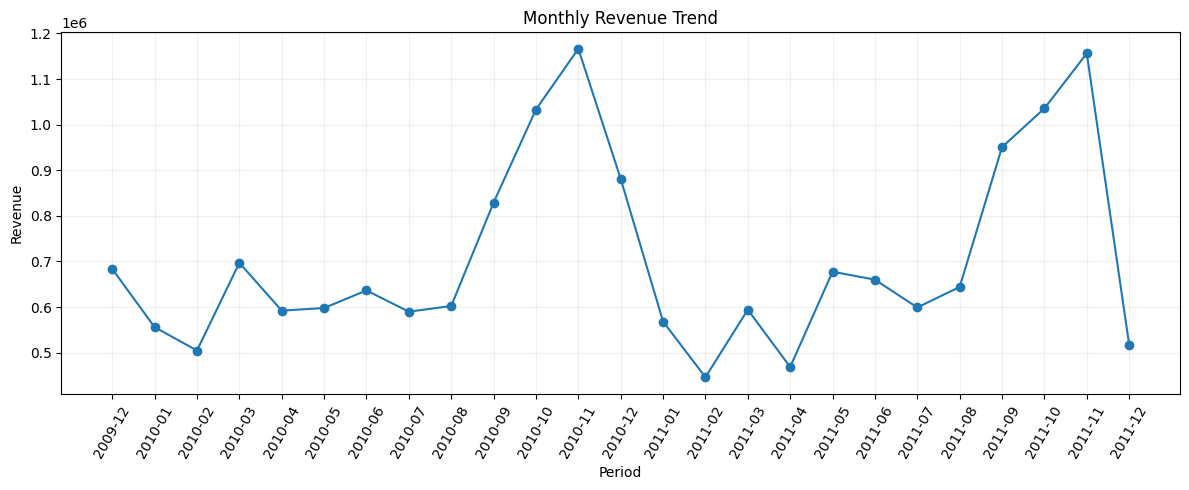

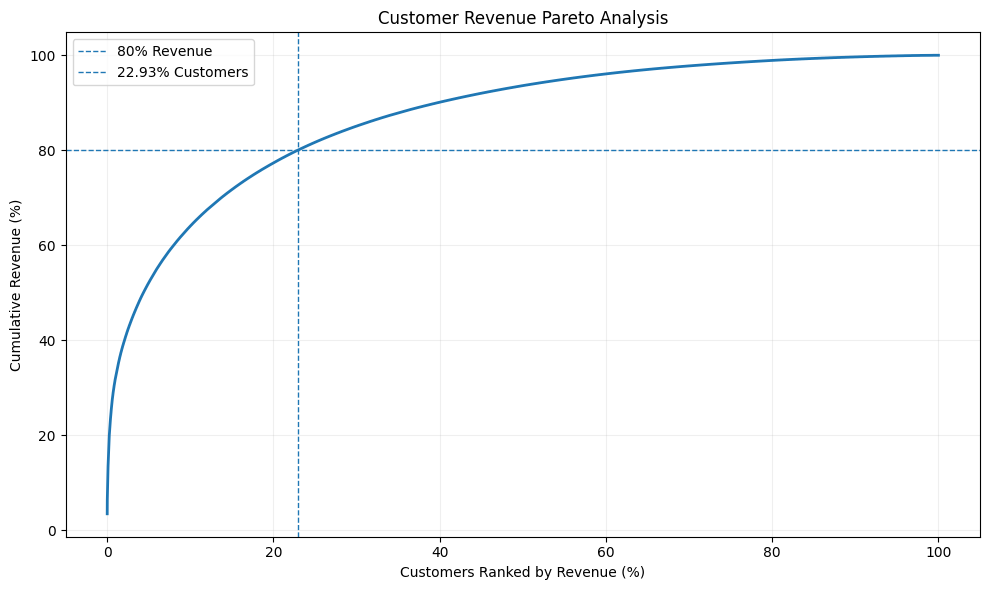

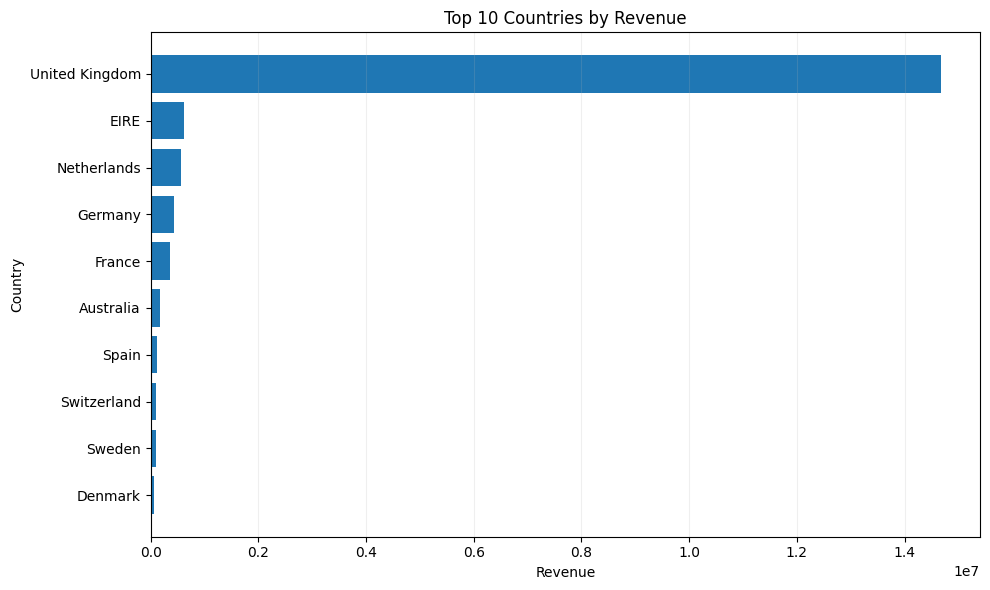

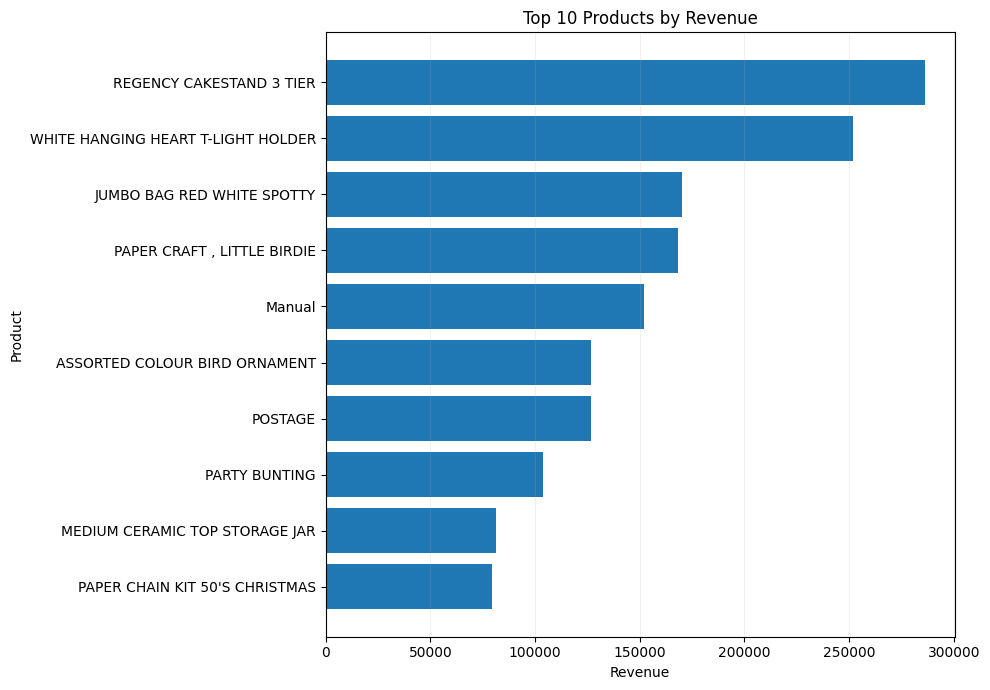

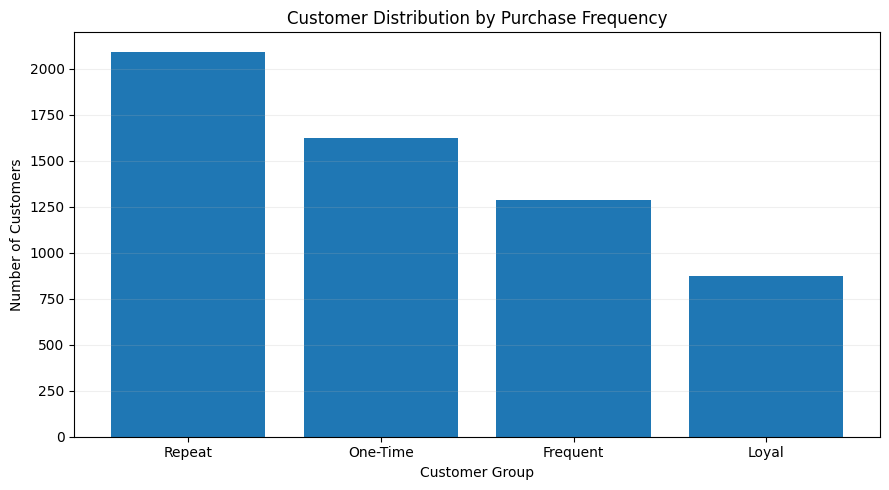


EXECUTIVE INSIGHTS

Total revenue: 17,685,460.64
Total customers: 5,878
Total orders: 36,969

Top revenue country:
United Kingdom → 14,666,669.08 (82.93% of revenue)

Top product by revenue:
REGENCY CAKESTAND 3 TIER → 285,992.35 (1.62% of revenue)

Pareto milestone:
22.93% of customers generate approximately 80.00% of revenue.

Executive dashboard completed successfully.


In [10]:
# ============================================================
# PROJECT 19 — END-TO-END RETAIL ETL & ANALYTICS PIPELINE
# STEP 7 — EXECUTIVE ANALYTICS DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 90)
print("EXECUTIVE RETAIL ANALYTICS DASHBOARD")
print("=" * 90)

# ------------------------------------------------------------
# 1. EXECUTIVE KPI
# ------------------------------------------------------------

kpi_query = """
SELECT
    COUNT(DISTINCT InvoiceNo) AS Total_Orders,
    COUNT(DISTINCT CustomerKey) AS Total_Customers,
    COUNT(DISTINCT ProductKey) AS Total_Products,
    SUM(Quantity) AS Total_Units_Sold,
    ROUND(SUM(Revenue), 2) AS Total_Revenue,
    ROUND(
        SUM(Revenue) * 1.0
        /
        COUNT(DISTINCT InvoiceNo),
        2
    ) AS Average_Order_Value,
    ROUND(
        SUM(Revenue) * 1.0
        /
        COUNT(DISTINCT CustomerKey),
        2
    ) AS Revenue_Per_Customer
FROM fact_sales;
"""

executive_kpi = pd.read_sql_query(
    kpi_query,
    conn
)

print(
    "\n" + "=" * 90
)
print("EXECUTIVE KPI")
print("=" * 90)

display(
    executive_kpi
)

# ------------------------------------------------------------
# 2. MONTHLY REVENUE
# ------------------------------------------------------------

monthly_query = """
WITH monthly AS (

    SELECT
        d.Year,
        d.Month,
        d.MonthName,
        SUM(f.Revenue) AS Revenue,
        COUNT(DISTINCT f.InvoiceNo) AS Orders,
        COUNT(DISTINCT f.CustomerKey) AS Customers
    FROM fact_sales f
    JOIN dim_date d
        ON f.DateKey = d.DateKey
    GROUP BY
        d.Year,
        d.Month,
        d.MonthName
)

SELECT
    Year,
    Month,
    MonthName,
    ROUND(Revenue, 2) AS Revenue,
    Orders,
    Customers,
    ROUND(
        (
            Revenue
            -
            LAG(Revenue) OVER (
                ORDER BY Year, Month
            )
        )
        /
        NULLIF(
            LAG(Revenue) OVER (
                ORDER BY Year, Month
            ),
            0
        )
        * 100,
        2
    ) AS MoM_Growth_Pct
FROM monthly
ORDER BY
    Year,
    Month;
"""

monthly_dashboard = pd.read_sql_query(
    monthly_query,
    conn
)

# ------------------------------------------------------------
# 3. CUSTOMER PARETO — CORRECTED
# ------------------------------------------------------------

pareto_query = """
WITH customer_revenue AS (

    SELECT
        CustomerKey,
        SUM(Revenue) AS Revenue
    FROM fact_sales
    GROUP BY
        CustomerKey
),

ranked AS (

    SELECT
        CustomerKey,
        Revenue,

        ROW_NUMBER() OVER (
            ORDER BY Revenue DESC
        ) AS Customer_Rank,

        COUNT(*) OVER () AS Total_Customers,

        SUM(Revenue) OVER (
            ORDER BY Revenue DESC
            ROWS BETWEEN UNBOUNDED PRECEDING
            AND CURRENT ROW
        ) AS Cumulative_Revenue,

        SUM(Revenue) OVER () AS Total_Revenue

    FROM customer_revenue
)

SELECT

    Customer_Rank,

    ROUND(
        Customer_Rank * 100.0
        /
        Total_Customers,
        2
    ) AS Customer_Pct,

    ROUND(
        Cumulative_Revenue * 100.0
        /
        Total_Revenue,
        2
    ) AS Cumulative_Revenue_Pct

FROM ranked

ORDER BY
    Customer_Rank;
"""

pareto_data = pd.read_sql_query(
    pareto_query,
    conn
)

# ------------------------------------------------------------
# 4. Find 80% revenue milestone
# ------------------------------------------------------------

pareto_80 = (
    pareto_data[
        pareto_data[
            "Cumulative_Revenue_Pct"
        ] >= 80
    ]
    .head(1)
)

if len(pareto_80) > 0:

    pareto_80_rank = int(
        pareto_80.iloc[0][
            "Customer_Rank"
        ]
    )

    pareto_80_pct = float(
        pareto_80.iloc[0][
            "Customer_Pct"
        ]
    )

    pareto_80_revenue = float(
        pareto_80.iloc[0][
            "Cumulative_Revenue_Pct"
        ]
    )

else:

    pareto_80_rank = np.nan
    pareto_80_pct = np.nan
    pareto_80_revenue = np.nan

print(
    "\n" + "=" * 90
)

print(
    "PARETO REVENUE ANALYSIS"
)

print(
    "=" * 90
)

print(
    f"\nCustomers required to reach ~80% revenue:"
)

print(
    f"Customer rank : "
    f"{pareto_80_rank:,}"
)

print(
    f"Customer share: "
    f"{pareto_80_pct:.2f}%"
)

print(
    f"Revenue share : "
    f"{pareto_80_revenue:.2f}%"
)

# ------------------------------------------------------------
# 5. COUNTRY PERFORMANCE
# ------------------------------------------------------------

country_query = """
SELECT
    c.Country,
    COUNT(DISTINCT f.CustomerKey) AS Customers,
    COUNT(DISTINCT f.InvoiceNo) AS Orders,
    ROUND(SUM(f.Revenue), 2) AS Revenue
FROM fact_sales f
JOIN dim_country c
    ON f.CountryKey = c.CountryKey
GROUP BY
    c.Country
ORDER BY
    Revenue DESC;
"""

country_dashboard = pd.read_sql_query(
    country_query,
    conn
)

# ------------------------------------------------------------
# 6. TOP PRODUCTS
# ------------------------------------------------------------

product_query = """
SELECT
    p.StockCode,
    p.Description,
    SUM(f.Quantity) AS Units_Sold,
    COUNT(DISTINCT f.InvoiceNo) AS Orders,
    ROUND(SUM(f.Revenue), 2) AS Revenue
FROM fact_sales f
JOIN dim_product p
    ON f.ProductKey = p.ProductKey
GROUP BY
    p.StockCode,
    p.Description
ORDER BY
    Revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(
    product_query,
    conn
)

# ------------------------------------------------------------
# 7. CUSTOMER FREQUENCY
# ------------------------------------------------------------

frequency_query = """
WITH customer_orders AS (

    SELECT
        CustomerKey,
        COUNT(
            DISTINCT InvoiceNo
        ) AS Orders
    FROM fact_sales
    GROUP BY
        CustomerKey
)

SELECT

    CASE

        WHEN Orders = 1
            THEN 'One-Time'

        WHEN Orders BETWEEN 2 AND 4
            THEN 'Repeat'

        WHEN Orders BETWEEN 5 AND 10
            THEN 'Frequent'

        ELSE 'Loyal'

    END AS Customer_Group,

    COUNT(*) AS Customers

FROM customer_orders

GROUP BY

    CASE

        WHEN Orders = 1
            THEN 'One-Time'

        WHEN Orders BETWEEN 2 AND 4
            THEN 'Repeat'

        WHEN Orders BETWEEN 5 AND 10
            THEN 'Frequent'

        ELSE 'Loyal'

    END

ORDER BY
    Customers DESC;
"""

customer_frequency = pd.read_sql_query(
    frequency_query,
    conn
)

# ------------------------------------------------------------
# 8. PRINT ANALYTICS TABLES
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "MONTHLY PERFORMANCE"
)

print(
    "=" * 90
)

display(
    monthly_dashboard
)

print(
    "\n" + "=" * 90
)

print(
    "TOP COUNTRIES"
)

print(
    "=" * 90
)

display(
    country_dashboard.head(10)
)

print(
    "\n" + "=" * 90
)

print(
    "TOP PRODUCTS"
)

print(
    "=" * 90
)

display(
    top_products
)

print(
    "\n" + "=" * 90
)

print(
    "CUSTOMER FREQUENCY"
)

print(
    "=" * 90
)

display(
    customer_frequency
)

# ------------------------------------------------------------
# 9. PLOT MONTHLY REVENUE
# ------------------------------------------------------------

monthly_dashboard[
    "Period"
] = (
    monthly_dashboard[
        "Year"
    ].astype(str)
    +
    "-"
    +
    monthly_dashboard[
        "Month"
    ]
    .astype(str)
    .str.zfill(2)
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    monthly_dashboard[
        "Period"
    ],
    monthly_dashboard[
        "Revenue"
    ],
    marker="o"
)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel(
    "Period"
)

plt.ylabel(
    "Revenue"
)

plt.xticks(
    rotation=60
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 10. PLOT PARETO CURVE
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    pareto_data[
        "Customer_Pct"
    ],
    pareto_data[
        "Cumulative_Revenue_Pct"
    ],
    linewidth=2
)

plt.axhline(
    80,
    linestyle="--",
    linewidth=1,
    label="80% Revenue"
)

plt.axvline(
    pareto_80_pct,
    linestyle="--",
    linewidth=1,
    label=(
        f"{pareto_80_pct:.2f}% Customers"
    )
)

plt.xlabel(
    "Customers Ranked by Revenue (%)"
)

plt.ylabel(
    "Cumulative Revenue (%)"
)

plt.title(
    "Customer Revenue Pareto Analysis"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 11. PLOT TOP COUNTRIES
# ------------------------------------------------------------

top_countries_plot = (
    country_dashboard
    .head(10)
    .sort_values(
        "Revenue"
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top_countries_plot[
        "Country"
    ],
    top_countries_plot[
        "Revenue"
    ]
)

plt.title(
    "Top 10 Countries by Revenue"
)

plt.xlabel(
    "Revenue"
)

plt.ylabel(
    "Country"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 12. PLOT TOP PRODUCTS
# ------------------------------------------------------------

top_products_plot = (
    top_products
    .sort_values(
        "Revenue"
    )
)

labels = (
    top_products_plot[
        "Description"
    ]
    .astype(str)
    .str[:35]
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    labels,
    top_products_plot[
        "Revenue"
    ]
)

plt.title(
    "Top 10 Products by Revenue"
)

plt.xlabel(
    "Revenue"
)

plt.ylabel(
    "Product"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 13. PLOT CUSTOMER FREQUENCY
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    customer_frequency[
        "Customer_Group"
    ],
    customer_frequency[
        "Customers"
    ]
)

plt.title(
    "Customer Distribution by Purchase Frequency"
)

plt.xlabel(
    "Customer Group"
)

plt.ylabel(
    "Number of Customers"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 14. Executive insights
# ------------------------------------------------------------

total_revenue = float(
    executive_kpi.iloc[0][
        "Total_Revenue"
    ]
)

total_customers = int(
    executive_kpi.iloc[0][
        "Total_Customers"
    ]
)

total_orders = int(
    executive_kpi.iloc[0][
        "Total_Orders"
    ]
)

top_country_name = (
    country_dashboard.iloc[0][
        "Country"
    ]
)

top_country_revenue = float(
    country_dashboard.iloc[0][
        "Revenue"
    ]
)

top_country_share = (
    top_country_revenue
    /
    total_revenue
    *
    100
)

top_product_name = (
    top_products.iloc[0][
        "Description"
    ]
)

top_product_revenue = float(
    top_products.iloc[0][
        "Revenue"
    ]
)

top_product_share = (
    top_product_revenue
    /
    total_revenue
    *
    100
)

# ------------------------------------------------------------
# 15. Final executive summary
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "EXECUTIVE INSIGHTS"
)

print(
    "=" * 90
)

print(
    f"\nTotal revenue: "
    f"{total_revenue:,.2f}"
)

print(
    f"Total customers: "
    f"{total_customers:,}"
)

print(
    f"Total orders: "
    f"{total_orders:,}"
)

print(
    f"\nTop revenue country:"
)

print(
    f"{top_country_name} "
    f"→ {top_country_revenue:,.2f} "
    f"({top_country_share:.2f}% of revenue)"
)

print(
    f"\nTop product by revenue:"
)

print(
    f"{top_product_name} "
    f"→ {top_product_revenue:,.2f} "
    f"({top_product_share:.2f}% of revenue)"
)

print(
    f"\nPareto milestone:"
)

print(
    f"{pareto_80_pct:.2f}% of customers "
    f"generate approximately "
    f"{pareto_80_revenue:.2f}% of revenue."
)

print(
    "\nExecutive dashboard completed successfully."
)

In [11]:
# ============================================================
# PROJECT 19 — END-TO-END RETAIL ETL & ANALYTICS PIPELINE
# STEP 8 — FINAL PIPELINE AUDIT & EXPORT
# ============================================================

import os
import json
import sqlite3
import pandas as pd
import numpy as np

print("=" * 90)
print("FINAL ETL PIPELINE AUDIT")
print("=" * 90)

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "raw_df",
    "sales_df",
    "fact_sales",
    "dim_customer",
    "dim_product",
    "dim_date",
    "dim_country",
    "conn"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:

    raise ValueError(
        f"Missing objects: {missing_objects}"
    )

# ------------------------------------------------------------
# 2. Source-to-final reconciliation
# ------------------------------------------------------------

source_rows = len(raw_df)
sales_rows = len(sales_df)
fact_rows = len(fact_sales)

source_revenue = (
    sales_df["Revenue"]
    .sum()
)

warehouse_revenue = (
    fact_sales["Revenue"]
    .sum()
)

revenue_difference = (
    source_revenue
    -
    warehouse_revenue
)

# ------------------------------------------------------------
# 3. Row-count reconciliation
# ------------------------------------------------------------

row_reconciliation = pd.DataFrame({
    "Layer": [
        "Raw Layer",
        "Transformed Sales Layer",
        "Fact Sales Layer"
    ],

    "Rows": [
        source_rows,
        sales_rows,
        fact_rows
    ]
})

print(
    "\n" + "=" * 90
)

print(
    "PIPELINE ROW RECONCILIATION"
)

print(
    "=" * 90
)

display(
    row_reconciliation
)

# ------------------------------------------------------------
# 4. Data warehouse integrity checks
# ------------------------------------------------------------

checks = {

    "Fact rows match sales rows":
        len(fact_sales) == len(sales_df),

    "Unique SalesKey":
        fact_sales[
            "SalesKey"
        ].nunique()
        ==
        len(fact_sales),

    "No missing CustomerKey":
        fact_sales[
            "CustomerKey"
        ].isna().sum() == 0,

    "No missing ProductKey":
        fact_sales[
            "ProductKey"
        ].isna().sum() == 0,

    "No missing DateKey":
        fact_sales[
            "DateKey"
        ].isna().sum() == 0,

    "No missing CountryKey":
        fact_sales[
            "CountryKey"
        ].isna().sum() == 0,

    "No invalid quantity":
        (
            fact_sales[
                "Quantity"
            ] <= 0
        ).sum() == 0,

    "No invalid unit price":
        (
            fact_sales[
                "UnitPrice"
            ] <= 0
        ).sum() == 0,

    "No missing revenue":
        fact_sales[
            "Revenue"
        ].isna().sum() == 0,

    "Revenue reconciled":
        abs(
            revenue_difference
        ) < 0.01
}

audit_report = pd.DataFrame({
    "Check":
        list(checks.keys()),

    "Status":
        [
            "PASS" if value else "FAIL"
            for value in checks.values()
        ]
})

# ------------------------------------------------------------
# 5. Overall audit status
# ------------------------------------------------------------

overall_status = (
    "PASS"
    if audit_report[
        "Status"
    ].eq("PASS").all()
    else
    "FAIL"
)

print(
    "\n" + "=" * 90
)

print(
    "FINAL DATA WAREHOUSE AUDIT"
)

print(
    "=" * 90
)

display(
    audit_report
)

print(
    f"\nOVERALL PIPELINE STATUS: "
    f"{overall_status}"
)

# ------------------------------------------------------------
# 6. Export analytical tables to CSV
# ------------------------------------------------------------

export_tables = {

    "executive_kpi.csv":
        executive_kpi,

    "monthly_revenue.csv":
        monthly_dashboard,

    "country_performance.csv":
        country_dashboard,

    "top_products.csv":
        top_products,

    "customer_frequency.csv":
        customer_frequency,

    "customer_contribution.csv":
        customer_contribution,

    "customer_concentration.csv":
        customer_concentration,

    "repeat_behavior.csv":
        repeat_behavior,

    "customer_quartile.csv":
        customer_quartile,

    "monthly_customer_activity.csv":
        monthly_customer,

    "country_contribution.csv":
        country_contribution
}

export_dir = "project19_exports"

os.makedirs(
    export_dir,
    exist_ok=True
)

print(
    "\nExporting analytical results..."
)

for filename, dataframe in (
    export_tables.items()
):

    output_path = os.path.join(
        export_dir,
        filename
    )

    dataframe.to_csv(
        output_path,
        index=False
    )

    print(
        f"PASS — {filename}"
    )

# ------------------------------------------------------------
# 7. Export warehouse tables to CSV
# ------------------------------------------------------------

warehouse_exports = {

    "fact_sales.csv":
        fact_sales,

    "dim_customer.csv":
        dim_customer,

    "dim_product.csv":
        dim_product,

    "dim_date.csv":
        dim_date,

    "dim_country.csv":
        dim_country
}

warehouse_dir = os.path.join(
    export_dir,
    "warehouse"
)

os.makedirs(
    warehouse_dir,
    exist_ok=True
)

print(
    "\nExporting warehouse tables..."
)

for filename, dataframe in (
    warehouse_exports.items()
):

    output_path = os.path.join(
        warehouse_dir,
        filename
    )

    dataframe.to_csv(
        output_path,
        index=False
    )

    print(
        f"PASS — warehouse/{filename}"
    )

# ------------------------------------------------------------
# 8. Save pipeline metadata
# ------------------------------------------------------------

metadata = {

    "project":
        "Project 19 — End-to-End Retail ETL & Analytics Pipeline",

    "database":
        "retail_analytics.db",

    "raw_rows":
        int(source_rows),

    "final_sales_rows":
        int(sales_rows),

    "fact_sales_rows":
        int(fact_rows),

    "customers":
        int(
            dim_customer[
                "CustomerID"
            ].nunique()
        ),

    "products":
        int(
            len(dim_product)
        ),

    "countries":
        int(
            len(dim_country)
        ),

    "total_revenue":
        float(
            warehouse_revenue
        ),

    "revenue_difference":
        float(
            revenue_difference
        ),

    "pipeline_status":
        overall_status
}

metadata_path = os.path.join(
    export_dir,
    "pipeline_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print(
    f"\nPASS — pipeline_metadata.json"
)

# ------------------------------------------------------------
# 9. Verify SQLite database exists
# ------------------------------------------------------------

database_exists = (
    os.path.exists(
        "retail_analytics.db"
    )
)

database_size = (
    os.path.getsize(
        "retail_analytics.db"
    )
    /
    (1024 ** 2)
    if database_exists
    else 0
)

print(
    "\n" + "=" * 90
)

print(
    "DATABASE ARTIFACT"
)

print(
    "=" * 90
)

print(
    f"Database exists : "
    f"{database_exists}"
)

print(
    f"Database size   : "
    f"{database_size:.2f} MB"
)

# ------------------------------------------------------------
# 10. Final analytics summary
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "PROJECT 19 FINAL SUMMARY"
)

print(
    "=" * 90
)

print(
    f"\nRaw records            : "
    f"{source_rows:,}"
)

print(
    f"Final sales records    : "
    f"{sales_rows:,}"
)

print(
    f"Fact records           : "
    f"{fact_rows:,}"
)

print(
    f"Customers              : "
    f"{len(dim_customer):,}"
)

print(
    f"Products               : "
    f"{len(dim_product):,}"
)

print(
    f"Countries              : "
    f"{len(dim_country):,}"
)

print(
    f"Revenue                : "
    f"{warehouse_revenue:,.2f}"
)

print(
    f"Revenue reconciliation : "
    f"{'PASS' if abs(revenue_difference) < 0.01 else 'FAIL'}"
)

print(
    f"\nPipeline status        : "
    f"{overall_status}"
)

print(
    "\nExport directory:"
)

print(
    os.path.abspath(
        export_dir
    )
)

print(
    "\nProject 19 pipeline audit completed."
)

FINAL ETL PIPELINE AUDIT

PIPELINE ROW RECONCILIATION


,Layer,Rows
0,Raw Layer,1067371
1,Transformed Sales Layer,793609
2,Fact Sales Layer,793609



FINAL DATA WAREHOUSE AUDIT


,Check,Status
0,Fact rows match sales rows,PASS
1,Unique SalesKey,PASS
2,No missing CustomerKey,PASS
3,No missing ProductKey,PASS
4,No missing DateKey,PASS
5,No missing CountryKey,PASS
6,No invalid quantity,PASS
7,No invalid unit price,PASS
8,No missing revenue,PASS
9,Revenue reconciled,PASS



OVERALL PIPELINE STATUS: PASS

Exporting analytical results...
PASS — executive_kpi.csv
PASS — monthly_revenue.csv
PASS — country_performance.csv
PASS — top_products.csv
PASS — customer_frequency.csv
PASS — customer_contribution.csv
PASS — customer_concentration.csv
PASS — repeat_behavior.csv
PASS — customer_quartile.csv
PASS — monthly_customer_activity.csv
PASS — country_contribution.csv

Exporting warehouse tables...
PASS — warehouse/fact_sales.csv
PASS — warehouse/dim_customer.csv
PASS — warehouse/dim_product.csv
PASS — warehouse/dim_date.csv
PASS — warehouse/dim_country.csv

PASS — pipeline_metadata.json

DATABASE ARTIFACT
Database exists : True
Database size   : 83.96 MB

PROJECT 19 FINAL SUMMARY

Raw records            : 1,067,371
Final sales records    : 793,609
Fact records           : 793,609
Customers              : 5,878
Products               : 4,631
Countries              : 41
Revenue                : 17,685,460.64
Revenue reconciliation : PASS

Pipeline status        : P

## Key Findings

### 1. The ETL pipeline successfully transformed raw transaction data into an analytical warehouse

The project processed 1,067,371 raw transaction records and transformed them into 793,609 valid sales transaction lines.

The pipeline included extraction, data cleaning, validation, dimensional modeling, warehouse loading, and SQL-based analytics.

### 2. Data quality was enforced before analytical processing

The transformation layer removed records with missing customer identifiers, duplicate records, cancelled transactions, and invalid transaction values.

A dedicated data quality gate was implemented before the data entered the analytical warehouse.

The final quality gate passed all validation checks.

### 3. The analytical warehouse maintained data consistency

The star schema consisted of:

- `fact_sales`
- `dim_customer`
- `dim_product`
- `dim_date`
- `dim_country`

All foreign-key checks passed, the fact-table grain was validated, and revenue reconciliation returned a difference of 0.00.

### 4. The fact table was designed at transaction-line grain

The fact table uses `SalesKey` as a surrogate identifier and follows the rule:

```text
1 row = 1 transaction line


## Business Recommendations

```markdown
## Business Recommendations

### Prioritize High-Contribution Customers

Because approximately 22.93% of customers account for around 80% of revenue, customer strategies should consider revenue contribution when allocating retention and service resources.

High-contribution customers can receive more personalized engagement and retention programs.

### Maintain Continuous Data Quality Gates

The quality gate should remain a mandatory stage before data enters downstream analytical systems.

Future implementations should automatically reject or quarantine records that violate critical validation rules.

### Monitor the United Kingdom Market

The United Kingdom contributes approximately 82.93% of total revenue in this dataset.

This concentration creates both an important business opportunity and a potential dependency risk.

The business should continue monitoring the UK market while evaluating opportunities to grow other regions.

### Monitor Revenue Trends Over Time

Monthly revenue and growth should be monitored continuously to identify:

- Seasonal patterns
- Declining periods
- Revenue spikes
- Changes in purchasing behavior

This can support inventory and campaign planning.

### Develop Customer Retention Strategies

The presence of a substantial repeat and loyal customer population suggests that customer retention can be an important revenue driver.

Frequency-based customer segments can be used to differentiate retention strategies.

### Build Reusable Analytical Data Models

The star schema should be treated as a reusable analytical layer rather than recreating transformations for every analysis.

This improves consistency across reports and analytics workflows.

### Automate the ETL Pipeline

A production implementation could schedule the pipeline to automatically:

```text
Extract
→ Validate
→ Transform
→ Load
→ Test
→ Refresh Analytics


## Conclusion

```markdown
## Conclusion

This project developed an end-to-end retail ETL and analytics pipeline that transforms raw transaction data into a structured analytical warehouse and business intelligence layer.

The pipeline processed 1,067,371 raw transaction records and produced 793,609 valid sales transaction records after transformation and validation.

The workflow implemented:

- Data extraction
- Data cleaning
- Data quality validation
- Revenue calculation
- Star schema modeling
- SQLite data warehousing
- SQL business analytics
- Advanced SQL analysis
- Revenue reconciliation
- Pipeline auditing

The analytical warehouse was successfully structured using a star schema consisting of a central `fact_sales` table and four dimension tables:

```text
fact_sales
├── dim_customer
├── dim_product
├── dim_date
└── dim_country